# When Do Token Rows Transfer?

We replace a model's tied token matrix while keeping the transformer body unchanged at installation, then continue training both parts on English. The four experiments test whether the spelling effect depends on training-language match, training run, row-to-token assignment, or model initialization.

In [1]:
from __future__ import annotations

import math
import sys
import tomllib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Image, display
from scipy import stats


def find_repository_root(start: Path = Path.cwd()) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        pyproject_path = candidate / "pyproject.toml"
        if not pyproject_path.is_file():
            continue
        with pyproject_path.open("rb") as stream:
            project = tomllib.load(stream).get("project", {})
        if project.get("name") == "token-row-transplants":
            return candidate
    raise FileNotFoundError("run this notebook from the repository checkout")


ROOT = find_repository_root()
FIGURE_DIR = ROOT / "figures"
sys.path.insert(0, str(ROOT / "src"))

from token_row_transplants import plots  # noqa: E402

LANGUAGE_LABELS = {"spanish": "Spanish", "german": "German", "english": "English"}
LANGUAGE_ORDER = {"spanish": 0, "german": 1, "english": 2}
OUTCOME_LABELS = {
    "step_zero": "Before English continuation",
    "learning_curve_auc": "Across English continuation",
}
BODY_LABELS = {
    "spanish": "Spanish-trained body",
    "german": "German-trained body",
    "english": "English-trained body",
}
ROW_LABELS = {
    "initial": "Initial rows",
    "spanish_trained": "Spanish-trained rows",
    "german_trained": "German-trained rows",
    "english_trained": "English-trained rows",
}


def read_study_table(study: str, filename: str) -> pd.DataFrame:
    path = ROOT / "results" / study / filename
    table = pd.read_csv(path, keep_default_na=False)
    if table.empty:
        raise ValueError(f"empty result table: {path.relative_to(ROOT)}")
    return table


def display_table(
    table: pd.DataFrame,
    *,
    caption: str | None = None,
    formats: dict[str, str] | None = None,
) -> None:
    table_name = caption or "table"
    table_id = "".join(
        character.lower() for character in table_name if character.isalnum()
    )
    displayed_table = table.copy()
    displayed_formats = formats
    if caption:
        displayed_table.columns = pd.MultiIndex.from_product(
            [[caption], displayed_table.columns]
        )
        if formats:
            displayed_formats = {
                (caption, column): formatter for column, formatter in formats.items()
            }
    style = displayed_table.style.hide(axis="index").set_uuid(table_id)
    if displayed_formats:
        style = style.format(displayed_formats, na_rep="–")
    display(HTML(style.to_html()))


def interval(estimate: float, low: float, high: float, digits: int = 3) -> str:
    return f"{estimate:.{digits}f} [{low:.{digits}f}, {high:.{digits}f}]"


def claim_summary(claims: pd.DataFrame) -> pd.DataFrame:
    summary = claims[["claim", "decision", "adjusted_p"]].copy()
    summary["decision"] = summary["decision"].map(
        {
            "supported": "Supported",
            "not_supported": "Not supported",
            "not_established": "Not supported",
            "equivalent": "Equivalent",
        }
    )
    if summary["decision"].isna().any():
        raise ValueError("unrecognized claim decision")
    return summary.rename(
        columns={
            "claim": "Comparison",
            "decision": "Conclusion",
            "adjusted_p": "Holm-adjusted p",
        }
    )


def summarize_seed_values(
    table: pd.DataFrame,
    groups: list[str],
    value: str,
) -> pd.DataFrame:
    summary = (
        table.groupby(groups, sort=False)[value]
        .agg(n="count", mean="mean", sample_sd="std")
        .reset_index()
    )
    critical = summary["n"].map(lambda n: stats.t.ppf(0.975, int(n) - 1))
    half_width = critical * summary["sample_sd"] / summary["n"].map(math.sqrt)
    summary["ci95_low"] = summary["mean"] - half_width
    summary["ci95_high"] = summary["mean"] + half_width
    return summary


def summarize_perplexity_from_nll(
    table: pd.DataFrame,
    groups: list[str],
    nll_column: str,
) -> pd.DataFrame:
    summary = summarize_seed_values(table, groups, nll_column)
    summary["perplexity"] = summary["mean"].map(math.exp)
    summary["perplexity_ci95_low"] = summary["ci95_low"].map(math.exp)
    summary["perplexity_ci95_high"] = summary["ci95_high"].map(math.exp)
    return summary


def save_analysis_figure(figure: plt.Figure, name: str) -> None:
    plots.save_figure(figure, FIGURE_DIR, name)
    display(figure)
    plt.close(figure)

## Measurements

The spelling effect is the fitted relationship between Spanish-English or German-English spelling similarity and English whole-word surprisal. Each regression includes both similarity scores, English frequency, character length, and part of speech. A positive change relative to initial rows means a stronger spelling effect, not lower average English loss.

We measure the effect at installation and with a learning-curve summary across 6,100 English updates. Saved checkpoints are 0, 50, 100, 200, 400, 800, 1,500, 3,000, 6,000, and 6,100 updates. Figures summarize the independent units in the table below. Where seed- or pair-level estimates are available, faint points show them behind the larger mean markers. Checkpoint figures use mean lines and simultaneous bands instead. Where values are labeled, they are the plotted means. Prespecified directional comparisons use 95% intervals, equivalence comparisons use 90% intervals, and checkpoint bands are simultaneous 95% intervals. Claim-level p values are Holm-adjusted within each experiment.

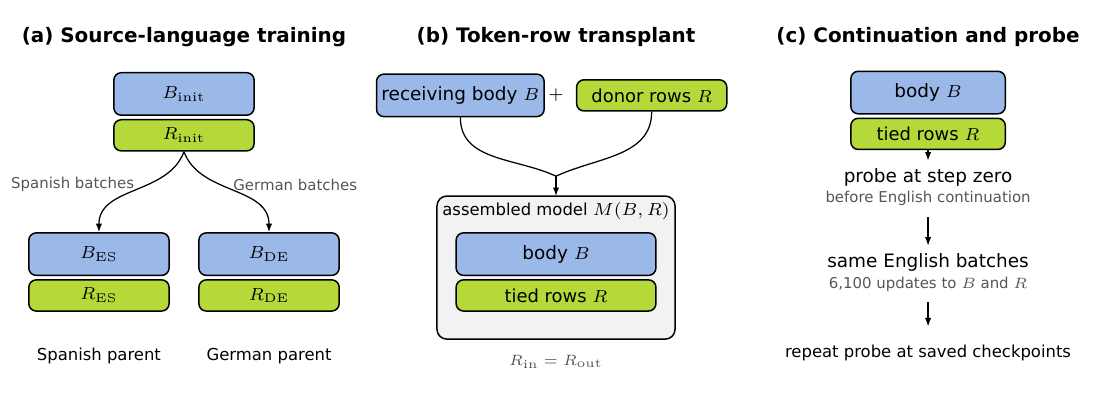

Experiment flow 
 
 
 Experiment 
 What changes 
 Independent unit 
 
 
 
 
 1. Training-language match 
 Training language of the receiving body and installed rows 
 12 seeds 
 
 
 2. Transfer across training runs 
 Co-trained, same-language other-run, and other-language rows 
 12 seeds 
 
 
 3. Row-to-token assignment 
 Correct assignment and three fixed frequency-local reassignments 
 12 seeds 
 
 
 Larger-decoder check 
 The step-zero row-assignment comparison in a larger decoder 
 14 seeds 
 
 
 4. Independent initialization 
 Rows copied between model families with different starting weights 
 12 initialization pairs

In [2]:
display(Image(filename=FIGURE_DIR / "token_row_transplant_overview.png", width=1000))

experiment_design = pd.DataFrame(
    [
        (
            "1. Training-language match",
            "Training language of the receiving body and installed rows",
            "12 seeds",
        ),
        (
            "2. Transfer across training runs",
            "Co-trained, same-language other-run, and other-language rows",
            "12 seeds",
        ),
        (
            "3. Row-to-token assignment",
            "Correct assignment and three fixed frequency-local reassignments",
            "12 seeds",
        ),
        (
            "Larger-decoder check",
            "The step-zero row-assignment comparison in a larger decoder",
            "14 seeds",
        ),
        (
            "4. Independent initialization",
            "Rows copied between model families with different starting weights",
            "12 initialization pairs",
        ),
    ],
    columns=["Experiment", "What changes", "Independent unit"],
)
display_table(experiment_design, caption="Experiment flow")

## 1. Training-language match

Each seed branches from one initialization into Spanish-, German-, and English-trained parents. Every receiving body is paired with initial rows and with rows trained in each language. The comparisons change one component while keeping the other fixed. Because matched rows and bodies also come from the same parent run, this experiment alone cannot separate language match from exact co-training.

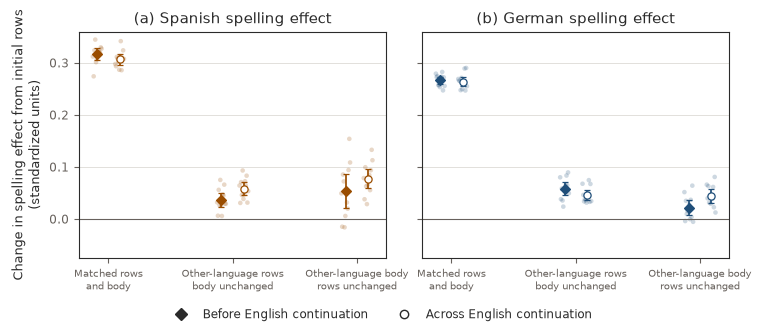

Training-language-match comparisons 
 
 
 Comparison 
 Conclusion 
 Holm-adjusted p 
 
 
 
 
 English-trained model advantage in English NLL 
 Supported 
 7.03e-21 
 
 
 English rows reduce the non-English-body NLL gap 
 Not supported 
 1 
 
 
 Residual NLL gap from the receiving body 
 Supported 
 1.02e-14 
 
 
 Larger spelling effect when rows and body share a training language 
 Supported 
 2.96e-10 
 
 
 Matched-language rows over other-language rows 
 Supported 
 1.7e-12 
 
 
 Cross-body row effect within the 0.10 equivalence range 
 Equivalent 
 0.0257

In [3]:
training_claims = read_study_table("training_language_match", "claims.csv")
training_components = read_study_table("training_language_match", "components.csv")
training_seed_estimates = read_study_table(
    "training_language_match", "seed_estimates.csv"
)
training_performance = read_study_table("training_language_match", "performance.csv")
training_performance_seeds = read_study_table(
    "training_language_match", "performance_seed_values.csv"
)
training_english_checkpoints = read_study_table(
    "training_language_match", "english_nll_checkpoints.csv"
)
training_spelling_checkpoints = read_study_table(
    "training_language_match", "spelling_checkpoints.csv"
)
training_spelling_sensitivity = read_study_table(
    "training_language_match", "spelling_sensitivity.csv"
)

save_analysis_figure(
    plots.training_language_match_spelling_effects(training_seed_estimates),
    "training_language_match_spelling_effects",
)
display_table(
    claim_summary(training_claims),
    caption="Training-language-match comparisons",
    formats={"Holm-adjusted p": "{:.3g}"},
)

Matched Spanish and German rows have their largest spelling effect on a body trained in the same language. Rows have a larger effect in the matching body, and each source-trained body favors rows trained on its language. In the prespecified standardized whole-word analysis, every cross-body estimate and 90% interval lies inside the ±0.10 equivalence range.

In [4]:
training_spelling_components = training_components.loc[
    training_components["outcome"].isin(OUTCOME_LABELS),
    [
        "language",
        "contrast_id",
        "outcome",
        "estimate",
        "ci_confidence",
        "ci_low",
        "ci_high",
    ],
].copy()
training_spelling_components["Language"] = training_spelling_components["language"].map(
    LANGUAGE_LABELS
)
training_spelling_components["Outcome"] = training_spelling_components["outcome"].map(
    OUTCOME_LABELS
)
training_spelling_components["Comparison"] = training_spelling_components[
    "contrast_id"
].map(
    {
        "spanish_matched_benefit": "Matched rows minus initial rows",
        "german_matched_benefit": "Matched rows minus initial rows",
        "spanish_body_moderation": "Matched-body difference",
        "german_body_moderation": "Matched-body difference",
        "spanish_over_german_rows_on_spanish_body": (
            "Matched-language rows minus other-language rows"
        ),
        "german_over_spanish_rows_on_german_body": (
            "Matched-language rows minus other-language rows"
        ),
        "spanish_rows_on_german_body": (
            "Rows on the other-language body minus initial rows"
        ),
        "german_rows_on_spanish_body": (
            "Rows on the other-language body minus initial rows"
        ),
    }
)
training_spelling_components["Estimate [interval]"] = (
    training_spelling_components.apply(
        lambda row: interval(row["estimate"], row["ci_low"], row["ci_high"]), axis=1
    )
)
training_spelling_components["Coverage"] = training_spelling_components[
    "ci_confidence"
].map(lambda value: f"{100 * value:.0f}%")
display_table(
    training_spelling_components[
        [
            "Language",
            "Comparison",
            "Outcome",
            "Estimate [interval]",
            "Coverage",
        ]
    ],
    caption="Spelling-effect estimates",
)

Spelling-effect estimates 
 
 
 Language 
 Comparison 
 Outcome 
 Estimate [interval] 
 Coverage 
 
 
 
 
 Spanish 
 Matched rows minus initial rows 
 Before English continuation 
 0.317 [0.306, 0.328] 
 95% 
 
 
 Spanish 
 Matched rows minus initial rows 
 Across English continuation 
 0.307 [0.297, 0.317] 
 95% 
 
 
 German 
 Matched rows minus initial rows 
 Before English continuation 
 0.266 [0.259, 0.273] 
 95% 
 
 
 German 
 Matched rows minus initial rows 
 Across English continuation 
 0.264 [0.255, 0.273] 
 95% 
 
 
 Spanish 
 Matched-body difference 
 Before English continuation 
 0.264 [0.237, 0.290] 
 95% 
 
 
 Spanish 
 Matched-body difference 
 Across English continuation 
 0.229 [0.213, 0.245] 
 95% 
 
 
 German 
 Matched-body difference 
 Before English continuation 
 0.245 [0.233, 0.257] 
 95% 
 
 
 German 
 Matched-body difference 
 Across English continuation 
 0.219 [0.212, 0.227] 
 95% 
 
 
 Spanish 
 Matched-language rows minus other-language rows 
 Before English continuation 
 0.280 [0.263, 0.296] 
 95% 
 
 
 Spanish 
 Matched-language rows minus other-language rows 
 Across English continuation 
 0.249 [0.234, 0.264] 
 95% 
 
 
 German 
 Matched-language rows minus other-language rows 
 Before English continuation 
 0.208 [0.197, 0.219] 
 95% 
 
 
 German 
 Matched-language rows minus other-language rows 
 Across English continuation 
 0.218 [0.212, 0.224] 
 95% 
 
 
 Spanish 
 Rows on the other-language body minus initial rows 
 Before English continuation 
 0.053 [0.026, 0.080] 
 90% 
 
 
 Spanish 
 Rows on the other-language body minus initial rows 
 Across English continuation 
 0.078 [0.062, 0.093] 
 90% 
 
 
 German 
 Rows on the other-language body minus initial rows 
 Before English continuation 
 0.021 [0.010, 0.033] 
 90% 
 
 
 German 
 Rows on the other-language body minus initial rows 
 Across English continuation 
 0.044 [0.034, 0.055] 
 90%

### English performance

The spelling effect is not a measure of overall English modeling. The English-trained body with English-trained rows has the lowest final English perplexity. On source-trained bodies, English rows have higher NLL at installation and higher log-step-weighted NLL than matched source rows, even though their final perplexity is slightly lower. NLL comparisons below subtract the second named condition from the first; lower NLL is better.

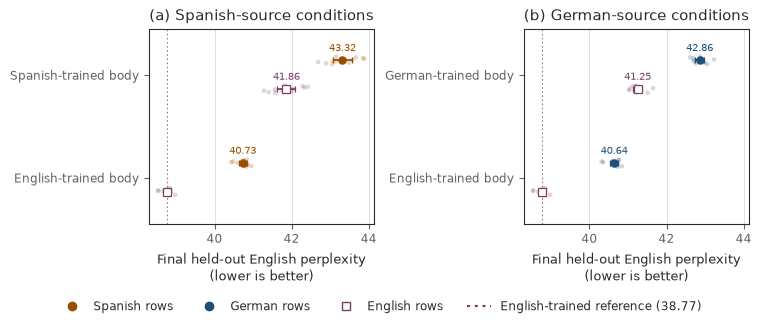

Training-language-match English performance 
 
 
 Receiving body 
 Installed rows 
 Installation English NLL 
 Log-step-weighted English NLL 
 Final English perplexity 
 
 
 
 
 Spanish-trained body 
 Initial rows 
 9.841 [9.817, 9.866] 
 6.825 [6.816, 6.834] 
 43.96 [43.74, 44.18] 
 
 
 Spanish-trained body 
 Spanish-trained rows 
 7.182 [7.150, 7.215] 
 5.574 [5.560, 5.589] 
 43.32 [43.08, 43.56] 
 
 
 Spanish-trained body 
 German-trained rows 
 10.240 [9.979, 10.502] 
 6.563 [6.498, 6.629] 
 44.29 [44.03, 44.54] 
 
 
 Spanish-trained body 
 English-trained rows 
 8.638 [8.462, 8.814] 
 5.698 [5.659, 5.737] 
 41.86 [41.63, 42.10] 
 
 
 German-trained body 
 Initial rows 
 9.825 [9.804, 9.846] 
 6.810 [6.803, 6.818] 
 43.48 [43.36, 43.60] 
 
 
 German-trained body 
 Spanish-trained rows 
 9.855 [9.673, 10.036] 
 6.468 [6.422, 6.513] 
 43.79 [43.66, 43.91] 
 
 
 German-trained body 
 German-trained rows 
 7.285 [7.261, 7.309] 
 5.583 [5.573, 5.593] 
 42.86 [42.75, 42.97] 
 
 
 German-trained body 
 English-trained rows 
 8.306 [8.167, 8.446] 
 5.617 [5.585, 5.650] 
 41.25 [41.14, 41.37] 
 
 
 English-trained body 
 Initial rows 
 9.595 [9.577, 9.612] 
 6.531 [6.524, 6.538] 
 40.09 [40.01, 40.17] 
 
 
 English-trained body 
 Spanish-trained rows 
 9.957 [9.514, 10.401] 
 6.262 [6.163, 6.360] 
 40.73 [40.63, 40.83] 
 
 
 English-trained body 
 German-trained rows 
 10.474 [10.107, 10.841] 
 6.371 [6.284, 6.459] 
 40.64 [40.54, 40.74] 
 
 
 English-trained body 
 English-trained rows 
 3.925 [3.922, 3.927] 
 3.925 [3.922, 3.927] 
 38.77 [38.68, 38.85]

English NLL comparisons 
 
 
 Language 
 Comparison 
 Outcome 
 Estimate [95% interval] 
 
 
 
 
 Spanish 
 Matched assembly minus English-trained model 
 At row installation 
 3.258 [3.225, 3.291] 
 
 
 Spanish 
 Matched assembly minus English-trained model 
 Across English continuation 
 1.650 [1.635, 1.664] 
 
 
 German 
 Matched assembly minus English-trained model 
 At row installation 
 3.360 [3.336, 3.384] 
 
 
 German 
 Matched assembly minus English-trained model 
 Across English continuation 
 1.659 [1.649, 1.669] 
 
 
 Spanish 
 Source rows minus English rows in the source-trained body 
 At row installation 
 -1.456 [-1.637, -1.274] 
 
 
 Spanish 
 Source rows minus English rows in the source-trained body 
 Across English continuation 
 -0.123 [-0.164, -0.082] 
 
 
 German 
 Source rows minus English rows in the source-trained body 
 At row installation 
 -1.022 [-1.153, -0.890] 
 
 
 German 
 Source rows minus English rows in the source-trained body 
 Across English continuation 
 -0.034 [-0.065, -0.003] 
 
 
 Spanish 
 Source-trained body with English rows minus English-trained model 
 At row installation 
 4.713 [4.538, 4.889] 
 
 
 Spanish 
 Source-trained body with English rows minus English-trained model 
 Across English continuation 
 1.773 [1.734, 1.812] 
 
 
 German 
 Source-trained body with English rows minus English-trained model 
 At row installation 
 4.382 [4.243, 4.520] 
 
 
 German 
 Source-trained body with English rows minus English-trained model 
 Across English continuation 
 1.693 [1.661, 1.725]

In [5]:
save_analysis_figure(
    plots.training_language_match_final_perplexity(
        training_performance, training_performance_seeds
    ),
    "training_language_match_final_perplexity",
)

performance_table = training_performance.copy()
performance_table["Receiving body"] = performance_table["receiving_body_language"].map(
    BODY_LABELS
)
performance_table["Installed rows"] = performance_table["installed_rows"].map(
    ROW_LABELS
)
performance_table["Installation English NLL"] = performance_table.apply(
    lambda row: interval(
        row["installation_english_nll"],
        row["installation_english_nll_ci95_low"],
        row["installation_english_nll_ci95_high"],
    ),
    axis=1,
)
performance_table["Log-step-weighted English NLL"] = performance_table.apply(
    lambda row: interval(
        row["weighted_english_nll"],
        row["weighted_english_nll_ci95_low"],
        row["weighted_english_nll_ci95_high"],
    ),
    axis=1,
)
performance_table["Final English perplexity"] = performance_table.apply(
    lambda row: interval(
        row["final_english_perplexity"],
        row["final_english_perplexity_ci95_low"],
        row["final_english_perplexity_ci95_high"],
        digits=2,
    ),
    axis=1,
)
display_table(
    performance_table[
        [
            "Receiving body",
            "Installed rows",
            "Installation English NLL",
            "Log-step-weighted English NLL",
            "Final English perplexity",
        ]
    ],
    caption="Training-language-match English performance",
)

english_nll_components = training_components.loc[
    training_components["outcome"].isin(("installation_nll", "weighted_english_nll"))
].copy()
english_nll_components["Language"] = english_nll_components["language"].map(
    LANGUAGE_LABELS
)
english_nll_components["Outcome"] = english_nll_components["outcome"].map(
    {
        "installation_nll": "At row installation",
        "weighted_english_nll": "Across English continuation",
    }
)
english_nll_components["Comparison"] = english_nll_components["contrast_id"].map(
    {
        "spanish_matched_minus_english_reference": (
            "Matched assembly minus English-trained model"
        ),
        "german_matched_minus_english_reference": (
            "Matched assembly minus English-trained model"
        ),
        "english_rows_on_spanish_body": (
            "Source rows minus English rows in the source-trained body"
        ),
        "english_rows_on_german_body": (
            "Source rows minus English rows in the source-trained body"
        ),
        "spanish_body_residual_with_english_rows": (
            "Source-trained body with English rows minus English-trained model"
        ),
        "german_body_residual_with_english_rows": (
            "Source-trained body with English rows minus English-trained model"
        ),
    }
)
english_nll_components["Estimate [95% interval]"] = english_nll_components.apply(
    lambda row: interval(row["estimate"], row["ci_low"], row["ci_high"]), axis=1
)
display_table(
    english_nll_components[
        ["Language", "Comparison", "Outcome", "Estimate [95% interval]"]
    ],
    caption="English NLL comparisons",
)

### Checkpoint trajectories

In source-trained bodies, English rows are worse at installation but better by update 50; their advantage then shrinks to about 0.04 nats per token by update 6,100. Matched source rows nonetheless have lower log-step-weighted NLL over the full continuation. On the English-trained body, the spelling effect from source-trained rows rises and then fades. The shaded bands are simultaneous across both languages and all ten saved checkpoints.

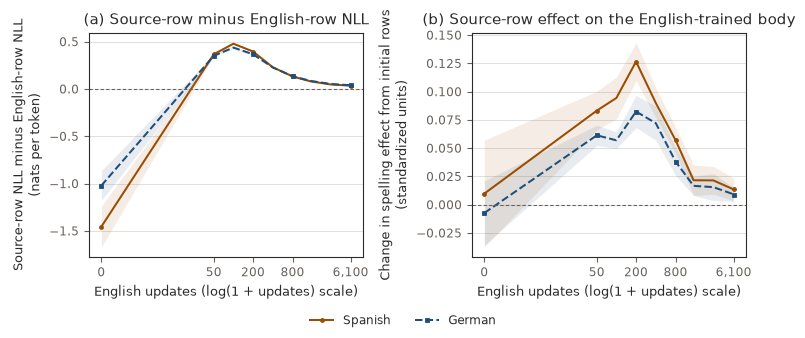

English continuation by checkpoint 
 
 
 Language 
 English updates 
 English-row minus source-row NLL [simultaneous 95% interval] 
 Source-row effect on English-trained body [simultaneous 95% interval] 
 
 
 
 
 Spanish 
 0 
 1.456 [1.240, 1.671] 
 0.010 [-0.038, 0.057] 
 
 
 Spanish 
 50 
 -0.366 [-0.383, -0.349] 
 0.083 [0.066, 0.100] 
 
 
 Spanish 
 100 
 -0.477 [-0.487, -0.468] 
 0.094 [0.076, 0.113] 
 
 
 Spanish 
 200 
 -0.395 [-0.402, -0.388] 
 0.126 [0.110, 0.143] 
 
 
 Spanish 
 400 
 -0.229 [-0.234, -0.224] 
 0.090 [0.077, 0.103] 
 
 
 Spanish 
 800 
 -0.131 [-0.134, -0.129] 
 0.057 [0.045, 0.069] 
 
 
 Spanish 
 1500 
 -0.080 [-0.082, -0.077] 
 0.022 [0.008, 0.035] 
 
 
 Spanish 
 3000 
 -0.047 [-0.049, -0.046] 
 0.021 [0.009, 0.034] 
 
 
 Spanish 
 6000 
 -0.034 [-0.036, -0.033] 
 0.014 [0.004, 0.024] 
 
 
 Spanish 
 6100 
 -0.034 [-0.035, -0.033] 
 0.014 [0.004, 0.023] 
 
 
 German 
 0 
 1.022 [0.865, 1.178] 
 -0.007 [-0.036, 0.021] 
 
 
 German 
 50 
 -0.350 [-0.364, -0.337] 
 0.061 [0.052, 0.070] 
 
 
 German 
 100 
 -0.437 [-0.450, -0.423] 
 0.057 [0.049, 0.064] 
 
 
 German 
 200 
 -0.366 [-0.378, -0.353] 
 0.082 [0.068, 0.097] 
 
 
 German 
 400 
 -0.227 [-0.233, -0.220] 
 0.072 [0.057, 0.087] 
 
 
 German 
 800 
 -0.133 [-0.135, -0.130] 
 0.038 [0.026, 0.050] 
 
 
 German 
 1500 
 -0.085 [-0.087, -0.082] 
 0.017 [0.008, 0.025] 
 
 
 German 
 3000 
 -0.052 [-0.054, -0.051] 
 0.015 [0.004, 0.027] 
 
 
 German 
 6000 
 -0.038 [-0.040, -0.037] 
 0.009 [0.003, 0.015] 
 
 
 German 
 6100 
 -0.038 [-0.040, -0.037] 
 0.009 [0.001, 0.016]

In [6]:
save_analysis_figure(
    plots.training_language_match_checkpoint_trajectories(
        training_english_checkpoints,
        training_spelling_checkpoints,
    ),
    "training_language_match_checkpoint_trajectories",
)

training_checkpoint_table = training_english_checkpoints.merge(
    training_spelling_checkpoints,
    left_on=["receiving_body_language", "english_updates"],
    right_on=["language", "english_updates"],
    validate="one_to_one",
)
training_checkpoint_table["Language"] = training_checkpoint_table["language"].map(
    LANGUAGE_LABELS
)
training_checkpoint_table[
    "English-row minus source-row NLL [simultaneous 95% interval]"
] = training_checkpoint_table.apply(
    lambda row: interval(
        row["english_rows_minus_source_rows_nll"],
        row["simultaneous95_low_x"],
        row["simultaneous95_high_x"],
    ),
    axis=1,
)
training_checkpoint_table[
    "Source-row effect on English-trained body [simultaneous 95% interval]"
] = training_checkpoint_table.apply(
    lambda row: interval(
        row["initial_minus_source_spelling_slope"],
        row["simultaneous95_low_y"],
        row["simultaneous95_high_y"],
    ),
    axis=1,
)
display_table(
    training_checkpoint_table[
        [
            "Language",
            "english_updates",
            "English-row minus source-row NLL [simultaneous 95% interval]",
            "Source-row effect on English-trained body [simultaneous 95% interval]",
        ]
    ].rename(columns={"english_updates": "English updates"}),
    caption="English continuation by checkpoint",
)

### Source-language loss

After English continuation, we restore each body's original source rows. The source-NLL increase is smallest after continuation with matched source rows. Initial and English rows produce larger increases, and other-language rows produce the largest. This measures how well the updated body still works with its restored source interface. Spanish and German use different held-out texts, so compare conditions within each language.

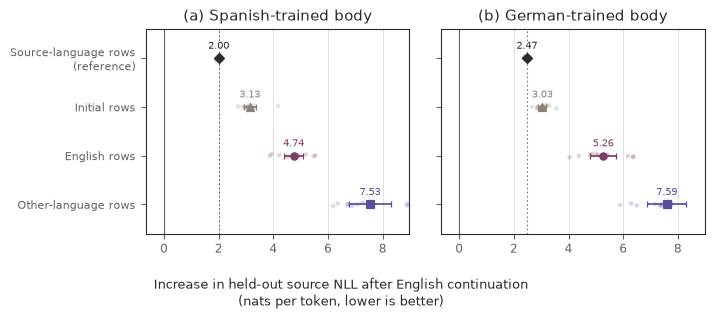

Held-out source loss 
 
 
 Receiving body 
 Installed rows 
 Source NLL before continuation 
 Source NLL after continuation 
 Increase [95% interval] 
 
 
 
 
 Spanish-trained body 
 Initial rows 
 3.743 
 6.877 
 3.135 [2.907, 3.362] 
 
 
 Spanish-trained body 
 Spanish-trained rows 
 3.743 
 5.738 
 1.995 [1.967, 2.023] 
 
 
 Spanish-trained body 
 German-trained rows 
 3.743 
 11.275 
 7.532 [6.757, 8.307] 
 
 
 Spanish-trained body 
 English-trained rows 
 3.743 
 8.479 
 4.737 [4.396, 5.078] 
 
 
 German-trained body 
 Initial rows 
 3.874 
 6.908 
 3.035 [2.883, 3.186] 
 
 
 German-trained body 
 Spanish-trained rows 
 3.874 
 11.464 
 7.590 [6.869, 8.311] 
 
 
 German-trained body 
 German-trained rows 
 3.874 
 6.347 
 2.473 [2.433, 2.513] 
 
 
 German-trained body 
 English-trained rows 
 3.874 
 9.138 
 5.264 [4.792, 5.737]

In [7]:
save_analysis_figure(
    plots.training_language_match_source_loss(
        training_performance, training_performance_seeds
    ),
    "training_language_match_source_loss",
)

source_performance = training_performance.loc[
    training_performance["receiving_body_language"].isin(("spanish", "german"))
].copy()
source_performance["Receiving body"] = source_performance[
    "receiving_body_language"
].map(BODY_LABELS)
source_performance["Installed rows"] = source_performance["installed_rows"].map(
    ROW_LABELS
)
source_performance["Source NLL before continuation"] = source_performance[
    "source_language_nll_before_continuation"
]
source_performance["Source NLL after continuation"] = source_performance[
    "source_language_nll_after_continuation"
]
source_performance["Increase [95% interval]"] = source_performance.apply(
    lambda row: interval(
        row["source_language_nll_increase"],
        row["source_language_nll_increase_ci95_low"],
        row["source_language_nll_increase_ci95_high"],
    ),
    axis=1,
)
display_table(
    source_performance[
        [
            "Receiving body",
            "Installed rows",
            "Source NLL before continuation",
            "Source NLL after continuation",
            "Increase [95% interval]",
        ]
    ],
    caption="Held-out source loss",
    formats={
        "Source NLL before continuation": "{:.3f}",
        "Source NLL after continuation": "{:.3f}",
    },
)

### Outcome-scale checks

The matched-language ordering remains under target-piece adjustment, a per-piece outcome, and the raw scale. Cross-body estimates are less stable, so the ±0.10 equivalence conclusion is limited to the prespecified standardized whole-word analysis.

In [8]:
training_sensitivity_summary = (
    training_spelling_sensitivity.groupby(["specification", "outcome"], sort=False)
    .agg(
        comparisons=("estimate", "size"),
        estimate_min=("estimate", "min"),
        estimate_max=("estimate", "max"),
        lowest_ci_endpoint=("ci95_low", "min"),
        highest_ci_endpoint=("ci95_high", "max"),
    )
    .reset_index()
)
training_sensitivity_summary["Outcome"] = training_sensitivity_summary["outcome"].map(
    OUTCOME_LABELS
)
training_sensitivity_summary["Specification"] = training_sensitivity_summary[
    "specification"
].map(
    {
        "target_piece_count_adjusted": "Target-piece-count adjusted",
        "per_target_piece": "Per target piece",
        "raw_scale": "Raw scale",
    }
)
training_sensitivity_summary = training_sensitivity_summary.sort_values(
    "specification",
    key=lambda specifications: specifications.map(
        {"target_piece_count_adjusted": 0, "per_target_piece": 1, "raw_scale": 2}
    ),
)
display_table(
    training_sensitivity_summary[
        [
            "Specification",
            "Outcome",
            "comparisons",
            "estimate_min",
            "estimate_max",
            "lowest_ci_endpoint",
            "highest_ci_endpoint",
        ]
    ].rename(
        columns={
            "comparisons": "Comparisons",
            "estimate_min": "Smallest estimate",
            "estimate_max": "Largest estimate",
            "lowest_ci_endpoint": "Lowest 95% endpoint",
            "highest_ci_endpoint": "Highest 95% endpoint",
        }
    ),
    caption="Spelling-effect sensitivity ranges",
    formats={
        "Smallest estimate": "{:.3f}",
        "Largest estimate": "{:.3f}",
        "Lowest 95% endpoint": "{:.3f}",
        "Highest 95% endpoint": "{:.3f}",
    },
)

Spelling-effect sensitivity ranges 
 
 
 Specification 
 Outcome 
 Comparisons 
 Smallest estimate 
 Largest estimate 
 Lowest 95% endpoint 
 Highest 95% endpoint 
 
 
 
 
 Target-piece-count adjusted 
 Before English continuation 
 12 
 -0.006 
 0.377 
 -0.036 
 0.389 
 
 
 Target-piece-count adjusted 
 Across English continuation 
 12 
 -0.023 
 0.366 
 -0.054 
 0.376 
 
 
 Per target piece 
 Before English continuation 
 12 
 -0.049 
 0.272 
 -0.129 
 0.344 
 
 
 Per target piece 
 Across English continuation 
 12 
 0.045 
 0.320 
 0.009 
 0.336 
 
 
 Raw scale 
 Before English continuation 
 12 
 0.018 
 1.503 
 -0.180 
 1.718 
 
 
 Raw scale 
 Across English continuation 
 12 
 1.245 
 7.419 
 0.818 
 7.910

## 2. Transfer across training runs

For each seed, two Spanish and two German parent runs begin from the same weights and use different batch orders. Each receiving body is evaluated with initial rows, its own co-trained rows, same-language rows from the other run, and other-language rows.

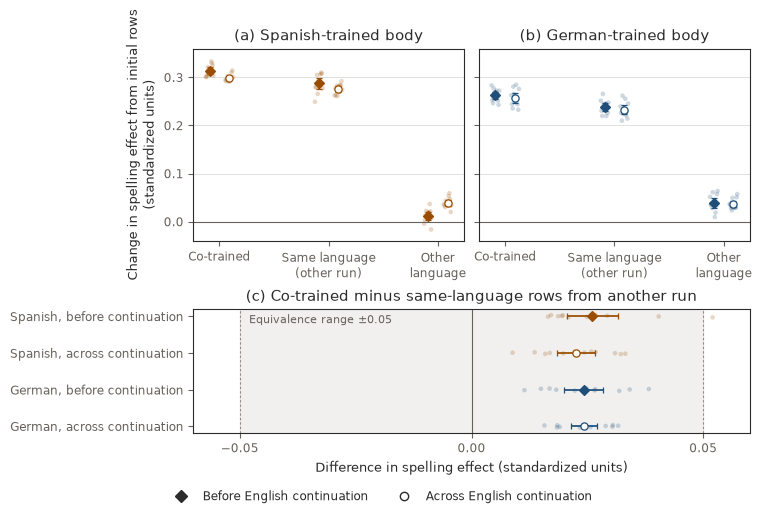

Transfer-across-runs comparisons 
 
 
 Comparison 
 Conclusion 
 Holm-adjusted p 
 
 
 
 
 Spelling effect from same-language rows trained in another run 
 Supported 
 2.77e-14 
 
 
 Same-language rows over other-language rows 
 Supported 
 1.86e-12 
 
 
 Co-trained and same-language cross-run rows within the 0.05 equivalence range 
 Equivalent 
 3.84e-06

In [9]:
cross_run_claims = read_study_table("cross_run_transfer", "claims.csv")
cross_run_claims = cross_run_claims.sort_values(
    "claim_id",
    key=lambda claim_ids: claim_ids.map(
        {
            "same_language_cross_run_effect": 0,
            "same_language_over_other_language": 1,
            "co_trained_and_cross_run_equivalence": 2,
        }
    ),
)
cross_run_components = read_study_table("cross_run_transfer", "components.csv")
cross_run_seed_estimates = read_study_table("cross_run_transfer", "seed_estimates.csv")
cross_run_checkpoints = read_study_table(
    "cross_run_transfer", "checkpoint_profiles.csv"
)
cross_run_english_performance = read_study_table(
    "cross_run_transfer", "english_performance.csv"
)
cross_run_source_costs = read_study_table(
    "cross_run_transfer", "source_language_costs.csv"
)
cross_run_source_contrasts = read_study_table(
    "cross_run_transfer", "source_language_contrasts.csv"
)
cross_run_spelling_sensitivity = read_study_table(
    "cross_run_transfer", "spelling_sensitivity.csv"
)

save_analysis_figure(
    plots.cross_run_transfer_spelling_effects(
        cross_run_components,
        cross_run_seed_estimates,
    ),
    "cross_run_transfer_spelling_effects",
)
display_table(
    claim_summary(cross_run_claims),
    caption="Transfer-across-runs comparisons",
    formats={"Holm-adjusted p": "{:.3g}"},
)

Rows from another same-language run produce a clear spelling effect and a larger one than other-language rows. The co-trained-minus-other-run differences are only +0.023 to +0.026 standardized units, and every 90% interval lies inside ±0.05.

In [10]:
cross_run_component_table = cross_run_components.copy()
cross_run_component_table["Language"] = cross_run_component_table["language"].map(
    LANGUAGE_LABELS
)
cross_run_component_table["Outcome"] = cross_run_component_table["outcome"].map(
    OUTCOME_LABELS
)
cross_run_component_table["Comparison"] = cross_run_component_table["claim_id"].map(
    {
        "same_language_cross_run_effect": (
            "Same-language rows from another run minus initial rows"
        ),
        "same_language_over_other_language": (
            "Same-language rows minus other-language rows"
        ),
        "co_trained_and_cross_run_equivalence": (
            "Co-trained rows minus same-language rows from another run"
        ),
    }
)
cross_run_component_table["Estimate [interval]"] = cross_run_component_table.apply(
    lambda row: interval(row["estimate"], row["ci_low"], row["ci_high"]), axis=1
)
cross_run_component_table["Coverage"] = cross_run_component_table["ci_confidence"].map(
    lambda value: f"{100 * value:.0f}%"
)
display_table(
    cross_run_component_table[
        [
            "Language",
            "Comparison",
            "Outcome",
            "Estimate [interval]",
            "Coverage",
        ]
    ],
    caption="Cross-run spelling-effect estimates",
)

retention_rows = []
for language in ("spanish", "german"):
    for outcome in OUTCOME_LABELS:
        same_run_row = cross_run_components.loc[
            cross_run_components["contrast_id"].eq(
                f"{language}_same_language_other_run_benefit"
            )
            & cross_run_components["outcome"].eq(outcome)
        ].iloc[0]
        co_trained_difference = cross_run_components.loc[
            cross_run_components["contrast_id"].eq(
                f"{language}_co_trained_minus_same_language_other_run"
            )
            & cross_run_components["outcome"].eq(outcome)
        ].iloc[0]
        same_run_effect = float(same_run_row["estimate"])
        co_trained_effect = same_run_effect + float(co_trained_difference["estimate"])
        retention_rows.append(
            {
                "Language": LANGUAGE_LABELS[language],
                "Outcome": OUTCOME_LABELS[outcome],
                "Co-trained effect": co_trained_effect,
                "Other-run same-language effect": same_run_effect,
                "Effect retained": 100 * same_run_effect / co_trained_effect,
            }
        )
retention_table = pd.DataFrame(retention_rows)
display_table(
    retention_table,
    caption="Effect retained across training runs",
    formats={
        "Co-trained effect": "{:.3f}",
        "Other-run same-language effect": "{:.3f}",
        "Effect retained": "{:.1f}%",
    },
)

Cross-run spelling-effect estimates 
 
 
 Language 
 Comparison 
 Outcome 
 Estimate [interval] 
 Coverage 
 
 
 
 
 Spanish 
 Same-language rows from another run minus initial rows 
 Before English continuation 
 0.287 [0.276, 0.299] 
 95% 
 
 
 Spanish 
 Same-language rows from another run minus initial rows 
 Across English continuation 
 0.276 [0.269, 0.282] 
 95% 
 
 
 German 
 Same-language rows from another run minus initial rows 
 Before English continuation 
 0.238 [0.230, 0.247] 
 95% 
 
 
 German 
 Same-language rows from another run minus initial rows 
 Across English continuation 
 0.233 [0.223, 0.243] 
 95% 
 
 
 Spanish 
 Same-language rows minus other-language rows 
 Before English continuation 
 0.276 [0.264, 0.287] 
 95% 
 
 
 Spanish 
 Same-language rows minus other-language rows 
 Across English continuation 
 0.237 [0.227, 0.246] 
 95% 
 
 
 German 
 Same-language rows minus other-language rows 
 Before English continuation 
 0.199 [0.186, 0.212] 
 95% 
 
 
 German 
 Same-language rows minus other-language rows 
 Across English continuation 
 0.197 [0.184, 0.209] 
 95% 
 
 
 Spanish 
 Co-trained rows minus same-language rows from another run 
 Before English continuation 
 0.026 [0.021, 0.032] 
 90% 
 
 
 Spanish 
 Co-trained rows minus same-language rows from another run 
 Across English continuation 
 0.023 [0.019, 0.027] 
 90% 
 
 
 German 
 Co-trained rows minus same-language rows from another run 
 Before English continuation 
 0.024 [0.020, 0.028] 
 90% 
 
 
 German 
 Co-trained rows minus same-language rows from another run 
 Across English continuation 
 0.024 [0.021, 0.027] 
 90%

Effect retained across training runs 
 
 
 Language 
 Outcome 
 Co-trained effect 
 Other-run same-language effect 
 Effect retained 
 
 
 
 
 Spanish 
 Before English continuation 
 0.313 
 0.287 
 91.7% 
 
 
 Spanish 
 Across English continuation 
 0.298 
 0.276 
 92.4% 
 
 
 German 
 Before English continuation 
 0.262 
 0.238 
 90.8% 
 
 
 German 
 Across English continuation 
 0.257 
 0.233 
 90.6%

### Checkpoint profiles

Same-language rows from another run stay close to the co-trained profile throughout English continuation. Other-language rows start near zero and remain below both same-language conditions. Lines show paired-seed means, and shaded bands show simultaneous 95% intervals across the ten checkpoints within each language and row condition. These trajectories are descriptive. The prespecified learning-curve outcome is calculated for each word, not as the area under the plotted mean line.

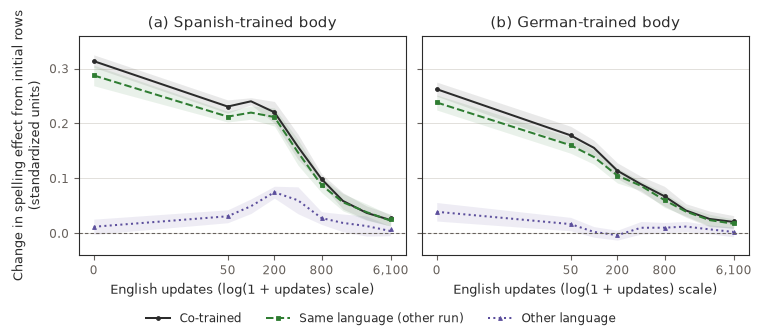

In [11]:
save_analysis_figure(
    plots.cross_run_checkpoint_profiles(cross_run_checkpoints),
    "cross_run_transfer_checkpoint_profiles",
)

### English and source-language performance

Final English perplexity changes little across the row conditions. With the original source rows restored, same-language rows from another run remain close to co-trained rows, while other-language rows produce much larger source loss.

Final English performance 
 
 
 Language 
 Condition 
 Final English perplexity [95% interval] 
 
 
 
 
 Spanish 
 Co-trained rows 
 41.89 [41.72, 42.07] 
 
 
 Spanish 
 Other-language rows 
 42.99 [42.81, 43.16] 
 
 
 Spanish 
 Same-language rows from another run 
 42.02 [41.85, 42.19] 
 
 
 Spanish 
 Initial rows 
 42.61 [42.45, 42.76] 
 
 
 German 
 Co-trained rows 
 41.57 [41.44, 41.70] 
 
 
 German 
 Other-language rows 
 42.44 [42.32, 42.56] 
 
 
 German 
 Same-language rows from another run 
 41.67 [41.54, 41.80] 
 
 
 German 
 Initial rows 
 42.16 [42.04, 42.29]

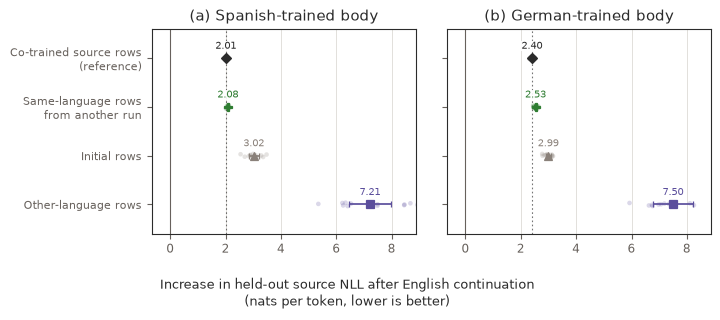

Final source-language performance 
 
 
 Language 
 Condition 
 Final source perplexity [95% interval] 
 
 
 
 
 Spanish 
 Co-trained rows 
 292.58 [288.30, 296.92] 
 
 
 Spanish 
 Initial rows 
 802.20 [676.58, 951.13] 
 
 
 Spanish 
 Other-language rows 
 53,459.20 [25,074.13, 113,977.46] 
 
 
 Spanish 
 Same-language rows from another run 
 314.79 [307.34, 322.42] 
 
 
 German 
 Co-trained rows 
 508.53 [491.90, 525.73] 
 
 
 German 
 Initial rows 
 917.21 [841.89, 999.27] 
 
 
 German 
 Other-language rows 
 83,117.95 [40,763.65, 169,479.27] 
 
 
 German 
 Same-language rows from another run 
 579.01 [556.03, 602.94]

Paired source-language comparisons 
 
 
 Language 
 Comparison 
 NLL difference [95% interval] 
 Perplexity ratio 
 
 
 
 
 Spanish 
 Co-trained minus initial 
 -1.009 [-1.183, -0.834] 
 0.36 
 
 
 Spanish 
 Same-language cross-run minus initial 
 -0.935 [-1.122, -0.749] 
 0.39 
 
 
 Spanish 
 Other-language minus initial 
 4.199 [3.476, 4.922] 
 66.64 
 
 
 Spanish 
 Same-language cross-run minus co-trained 
 0.073 [0.051, 0.095] 
 1.08 
 
 
 Spanish 
 Other-language minus same-language cross-run 
 5.135 [4.376, 5.894] 
 169.82 
 
 
 German 
 Co-trained minus initial 
 -0.590 [-0.691, -0.489] 
 0.55 
 
 
 German 
 Same-language cross-run minus initial 
 -0.460 [-0.570, -0.350] 
 0.63 
 
 
 German 
 Other-language minus initial 
 4.507 [3.766, 5.247] 
 90.62 
 
 
 German 
 Same-language cross-run minus co-trained 
 0.130 [0.107, 0.153] 
 1.14 
 
 
 German 
 Other-language minus same-language cross-run 
 4.967 [4.268, 5.666] 
 143.55

In [12]:
cross_run_english_summary = summarize_perplexity_from_nll(
    cross_run_english_performance,
    ["language", "condition"],
    "nll_nats_per_token",
)
cross_run_english_summary = cross_run_english_summary.sort_values(
    "language", key=lambda languages: languages.map(LANGUAGE_ORDER)
)
cross_run_english_summary["Language"] = cross_run_english_summary["language"].map(
    LANGUAGE_LABELS
)
cross_run_english_summary["Condition"] = cross_run_english_summary["condition"].map(
    {
        "co_trained": "Co-trained rows",
        "same_language_other_run": "Same-language rows from another run",
        "other_language": "Other-language rows",
        "initial": "Initial rows",
    }
)
cross_run_english_summary["Final English perplexity [95% interval]"] = (
    cross_run_english_summary.apply(
        lambda row: (
            f'{row["perplexity"]:,.2f} '
            f'[{row["perplexity_ci95_low"]:,.2f}, '
            f'{row["perplexity_ci95_high"]:,.2f}]'
        ),
        axis=1,
    )
)
display_table(
    cross_run_english_summary[
        ["Language", "Condition", "Final English perplexity [95% interval]"]
    ],
    caption="Final English performance",
)

save_analysis_figure(
    plots.cross_run_source_loss(cross_run_source_costs),
    "cross_run_transfer_source_loss",
)

cross_run_source_summary = summarize_perplexity_from_nll(
    cross_run_source_costs,
    ["source_language", "condition"],
    "final_source_nll",
)
cross_run_source_summary = cross_run_source_summary.sort_values(
    "source_language", key=lambda languages: languages.map(LANGUAGE_ORDER)
)
cross_run_source_summary["Language"] = cross_run_source_summary["source_language"].map(
    LANGUAGE_LABELS
)
cross_run_source_summary["Condition"] = cross_run_source_summary["condition"].map(
    {
        "co_trained": "Co-trained rows",
        "same_language_other_run": "Same-language rows from another run",
        "other_language": "Other-language rows",
        "initial": "Initial rows",
    }
)
cross_run_source_summary["Final source perplexity [95% interval]"] = (
    cross_run_source_summary.apply(
        lambda row: (
            f'{row["perplexity"]:,.2f} '
            f'[{row["perplexity_ci95_low"]:,.2f}, '
            f'{row["perplexity_ci95_high"]:,.2f}]'
        ),
        axis=1,
    )
)
display_table(
    cross_run_source_summary[
        ["Language", "Condition", "Final source perplexity [95% interval]"]
    ],
    caption="Final source-language performance",
)

source_contrast_table = cross_run_source_contrasts.copy()
source_contrast_table["Language"] = source_contrast_table["language"].map(
    LANGUAGE_LABELS
)
source_contrast_table = source_contrast_table.sort_values(
    "language", key=lambda languages: languages.map(LANGUAGE_ORDER)
)
source_contrast_table["Comparison"] = source_contrast_table["contrast"].map(
    {
        "co_trained_minus_initial": "Co-trained minus initial",
        "same_language_other_run_minus_initial": (
            "Same-language cross-run minus initial"
        ),
        "other_language_minus_initial": "Other-language minus initial",
        "same_language_other_run_minus_co_trained": (
            "Same-language cross-run minus co-trained"
        ),
        "other_language_minus_same_language_other_run": (
            "Other-language minus same-language cross-run"
        ),
    }
)
source_contrast_table["NLL difference [95% interval]"] = source_contrast_table.apply(
    lambda row: interval(row["estimate"], row["ci95_low"], row["ci95_high"]),
    axis=1,
)
display_table(
    source_contrast_table[
        [
            "Language",
            "Comparison",
            "NLL difference [95% interval]",
            "perplexity_ratio",
        ]
    ].rename(columns={"perplexity_ratio": "Perplexity ratio"}),
    caption="Paired source-language comparisons",
    formats={"Perplexity ratio": "{:.2f}"},
)

### Target-piece-count check

With target-piece count added, the same-language effect and same-language advantage remain positive, and the co-trained comparison remains inside its equivalence range. These sensitivity intervals are unadjusted; the formal claims use the prespecified model.

In [13]:
cross_run_sensitivity_table = cross_run_spelling_sensitivity.copy()
cross_run_sensitivity_table["Language"] = cross_run_sensitivity_table["language"].map(
    LANGUAGE_LABELS
)
cross_run_sensitivity_table["Outcome"] = cross_run_sensitivity_table["outcome"].map(
    OUTCOME_LABELS
)
cross_run_contrast_labels = (
    cross_run_components.drop_duplicates("contrast_id")
    .set_index("contrast_id")["contrast"]
    .to_dict()
)
cross_run_sensitivity_table["Comparison"] = cross_run_sensitivity_table[
    "contrast_id"
].map(cross_run_contrast_labels)
cross_run_sensitivity_table["Estimate [90% interval]"] = (
    cross_run_sensitivity_table.apply(
        lambda row: interval(row["estimate"], row["ci90_low"], row["ci90_high"]),
        axis=1,
    )
)
display_table(
    cross_run_sensitivity_table[
        ["Language", "Comparison", "Outcome", "Estimate [90% interval]"]
    ],
    caption="Target-piece-count-adjusted spelling effects",
)

Target-piece-count-adjusted spelling effects 
 
 
 Language 
 Comparison 
 Outcome 
 Estimate [90% interval] 
 
 
 
 
 Spanish 
 Spanish same-language cross-run spelling effect 
 Before English continuation 
 0.341 [0.330, 0.352] 
 
 
 German 
 German same-language cross-run spelling effect 
 Before English continuation 
 0.257 [0.250, 0.264] 
 
 
 Spanish 
 Spanish same-language versus other-language rows 
 Before English continuation 
 0.326 [0.315, 0.336] 
 
 
 German 
 German same-language versus other-language rows 
 Before English continuation 
 0.213 [0.202, 0.224] 
 
 
 Spanish 
 Spanish co-trained minus same-language other-run rows 
 Before English continuation 
 0.036 [0.029, 0.042] 
 
 
 German 
 German co-trained minus same-language other-run rows 
 Before English continuation 
 0.028 [0.023, 0.032] 
 
 
 Spanish 
 Spanish same-language cross-run spelling effect 
 Across English continuation 
 0.328 [0.323, 0.334] 
 
 
 German 
 German same-language cross-run spelling effect 
 Across English continuation 
 0.250 [0.241, 0.258] 
 
 
 Spanish 
 Spanish same-language versus other-language rows 
 Across English continuation 
 0.285 [0.277, 0.293] 
 
 
 German 
 German same-language versus other-language rows 
 Across English continuation 
 0.208 [0.197, 0.218] 
 
 
 Spanish 
 Spanish co-trained minus same-language other-run rows 
 Across English continuation 
 0.031 [0.027, 0.036] 
 
 
 German 
 German co-trained minus same-language other-run rows 
 Across English continuation 
 0.027 [0.024, 0.030]

## 3. Row-to-token assignment

This experiment holds the trained vectors fixed and changes only which token receives each vector. It compares the learned training-time token–vector pairing with three fixed, frequency-local reassignments. The three reassignments are interventions, not independent samples from a population of mappings.

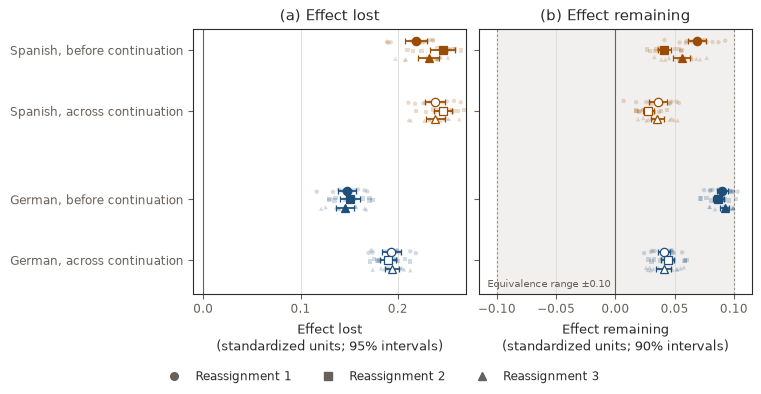

Row-to-token assignment comparisons 
 
 
 Comparison 
 Conclusion 
 Holm-adjusted p 
 
 
 
 
 Correctly assigned rows over reassigned rows 
 Supported 
 3.33e-12 
 
 
 Spelling effect remaining after reassignment within the 0.10 equivalence range 
 Equivalent 
 0.00254

In [14]:
assignment_claims = read_study_table("row_to_token_assignment", "claims.csv")
assignment_components = read_study_table("row_to_token_assignment", "components.csv")
assignment_seed_estimates = read_study_table(
    "row_to_token_assignment", "seed_estimates.csv"
)
assignment_checkpoints = read_study_table(
    "row_to_token_assignment", "assignment_checkpoints.csv"
)
assignment_piece_count = read_study_table(
    "row_to_token_assignment", "target_piece_count_sensitivity.csv"
)
assignment_outcome_sensitivity = read_study_table(
    "row_to_token_assignment", "outcome_sensitivity.csv"
)
assignment_mapping_sensitivity = read_study_table(
    "row_to_token_assignment", "mapping_sensitivity.csv"
)
assignment_bootstrap = read_study_table(
    "row_to_token_assignment", "word_bootstrap_summary.csv"
)

assignment_seed_counts = assignment_seed_estimates.groupby(
    ["contrast_id", "language", "outcome"]
)["seed"].nunique()
assert assignment_seed_counts.eq(12).all()

save_analysis_figure(
    plots.row_to_token_assignment_effects(
        assignment_components, assignment_seed_estimates
    ),
    "row_to_token_assignment_effects",
)
display_table(
    claim_summary(assignment_claims),
    caption="Row-to-token assignment comparisons",
    formats={"Holm-adjusted p": "{:.3g}"},
)

Panel (a) shows how much of the correctly assigned spelling effect is lost through each fixed reassignment. Panel (b) shows how much remains relative to initial rows. The two values add to the full trained-row effect. Color identifies language, shape identifies reassignment, and the larger markers are filled before continuation and open across continuation. Every 95% interval in panel (a) is above zero, and every 90% interval in panel (b) lies inside the prespecified ±0.10 range.

In [15]:
assignment_component_table = assignment_components.copy()
assignment_component_table["Language"] = assignment_component_table["language"].map(
    LANGUAGE_LABELS
)
assignment_component_table["Outcome"] = assignment_component_table["outcome"].map(
    OUTCOME_LABELS
)
assignment_component_table["Quantity"] = assignment_component_table["claim_id"].map(
    {
        "correct_assignment_advantage": "Correct-assignment advantage",
        "remaining_effect_after_reassignment": ("Effect remaining after reassignment"),
    }
)
assignment_component_table["Reassignment"] = assignment_component_table[
    "contrast_id"
].str.extract(r"map_(\d+)")[0]
assignment_component_table["Estimate [interval]"] = assignment_component_table.apply(
    lambda row: interval(row["estimate"], row["ci_low"], row["ci_high"]), axis=1
)
assignment_component_table["Coverage"] = assignment_component_table[
    "ci_confidence"
].map(lambda value: f"{100 * value:.0f}%")
display_table(
    assignment_component_table[
        [
            "Language",
            "Quantity",
            "Reassignment",
            "Outcome",
            "Estimate [interval]",
            "Coverage",
        ]
    ],
    caption="Row-assignment estimates",
)

Row-assignment estimates 
 
 
 Language 
 Quantity 
 Reassignment 
 Outcome 
 Estimate [interval] 
 Coverage 
 
 
 
 
 Spanish 
 Correct-assignment advantage 
 1 
 Before English continuation 
 0.218 [0.207, 0.230] 
 95% 
 
 
 Spanish 
 Correct-assignment advantage 
 2 
 Before English continuation 
 0.246 [0.233, 0.259] 
 95% 
 
 
 Spanish 
 Correct-assignment advantage 
 3 
 Before English continuation 
 0.232 [0.221, 0.243] 
 95% 
 
 
 Spanish 
 Correct-assignment advantage 
 1 
 Across English continuation 
 0.238 [0.228, 0.248] 
 95% 
 
 
 Spanish 
 Correct-assignment advantage 
 2 
 Across English continuation 
 0.246 [0.237, 0.255] 
 95% 
 
 
 Spanish 
 Correct-assignment advantage 
 3 
 Across English continuation 
 0.239 [0.229, 0.249] 
 95% 
 
 
 German 
 Correct-assignment advantage 
 1 
 Before English continuation 
 0.148 [0.139, 0.157] 
 95% 
 
 
 German 
 Correct-assignment advantage 
 2 
 Before English continuation 
 0.151 [0.141, 0.162] 
 95% 
 
 
 German 
 Correct-assignment advantage 
 3 
 Before English continuation 
 0.146 [0.137, 0.155] 
 95% 
 
 
 German 
 Correct-assignment advantage 
 1 
 Across English continuation 
 0.193 [0.184, 0.203] 
 95% 
 
 
 German 
 Correct-assignment advantage 
 2 
 Across English continuation 
 0.190 [0.182, 0.199] 
 95% 
 
 
 German 
 Correct-assignment advantage 
 3 
 Across English continuation 
 0.194 [0.187, 0.201] 
 95% 
 
 
 Spanish 
 Effect remaining after reassignment 
 1 
 Before English continuation 
 0.069 [0.062, 0.077] 
 90% 
 
 
 Spanish 
 Effect remaining after reassignment 
 2 
 Before English continuation 
 0.041 [0.036, 0.047] 
 90% 
 
 
 Spanish 
 Effect remaining after reassignment 
 3 
 Before English continuation 
 0.056 [0.049, 0.063] 
 90% 
 
 
 Spanish 
 Effect remaining after reassignment 
 1 
 Across English continuation 
 0.036 [0.028, 0.043] 
 90% 
 
 
 Spanish 
 Effect remaining after reassignment 
 2 
 Across English continuation 
 0.028 [0.023, 0.032] 
 90% 
 
 
 Spanish 
 Effect remaining after reassignment 
 3 
 Across English continuation 
 0.035 [0.030, 0.041] 
 90% 
 
 
 German 
 Effect remaining after reassignment 
 1 
 Before English continuation 
 0.090 [0.085, 0.095] 
 90% 
 
 
 German 
 Effect remaining after reassignment 
 2 
 Before English continuation 
 0.087 [0.082, 0.092] 
 90% 
 
 
 German 
 Effect remaining after reassignment 
 3 
 Before English continuation 
 0.092 [0.088, 0.096] 
 90% 
 
 
 German 
 Effect remaining after reassignment 
 1 
 Across English continuation 
 0.041 [0.036, 0.046] 
 90% 
 
 
 German 
 Effect remaining after reassignment 
 2 
 Across English continuation 
 0.044 [0.038, 0.050] 
 90% 
 
 
 German 
 Effect remaining after reassignment 
 3 
 Across English continuation 
 0.041 [0.034, 0.047] 
 90%

### Persistence through English continuation

The correct-assignment advantage becomes smaller during continuation but remains positive at update 6,100. The average effect remaining after reassignment becomes negative at several middle checkpoints before returning close to zero. The figure uses simultaneous intervals across all ten checkpoints.

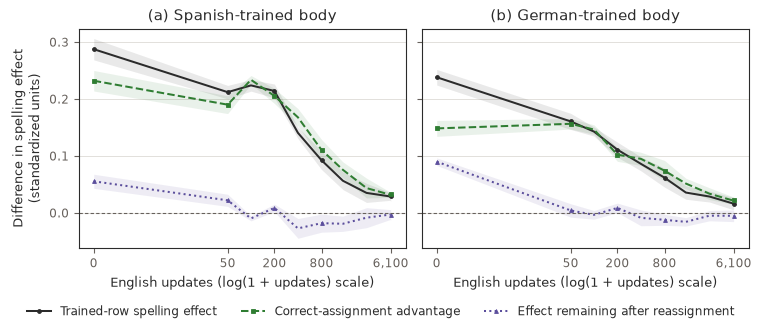

Assignment effects at the first and last checkpoints 
 
 
 Language 
 Quantity 
 Update 0 [simultaneous 95% interval] 
 Update 6,100 [simultaneous 95% interval] 
 Estimate retained 
 
 
 
 
 Spanish 
 Trained-row spelling effect 
 0.287 [0.269, 0.306] 
 0.029 [0.020, 0.038] 
 10.1% 
 
 
 Spanish 
 Correct-assignment advantage 
 0.232 [0.214, 0.250] 
 0.032 [0.027, 0.038] 
 13.9% 
 
 
 Spanish 
 Effect remaining after reassignment 
 0.055 [0.043, 0.068] 
 -0.003 [-0.013, 0.006] 
 – 
 
 
 German 
 Trained-row spelling effect 
 0.238 [0.224, 0.252] 
 0.016 [0.007, 0.026] 
 6.8% 
 
 
 German 
 Correct-assignment advantage 
 0.148 [0.134, 0.162] 
 0.022 [0.014, 0.030] 
 14.8% 
 
 
 German 
 Effect remaining after reassignment 
 0.090 [0.083, 0.096] 
 -0.006 [-0.015, 0.004] 
 –

In [16]:
save_analysis_figure(
    plots.row_to_token_assignment_persistence(assignment_checkpoints),
    "row_to_token_assignment_persistence",
)

persistence_quantity_labels = {
    "trained_row_effect": "Trained-row spelling effect",
    "correct_assignment_advantage": "Correct-assignment advantage",
    "remaining_effect_after_reassignment": "Effect remaining after reassignment",
}
persistence_rows = []
for (language, estimand), rows in assignment_checkpoints.groupby(
    ["language", "estimand"], sort=False
):
    start = rows.loc[rows["english_updates"].eq(0)].iloc[0]
    end = rows.loc[rows["english_updates"].eq(6100)].iloc[0]
    persistence_rows.append(
        {
            "Language": LANGUAGE_LABELS[language],
            "Quantity": persistence_quantity_labels[estimand],
            "Update 0 [simultaneous 95% interval]": interval(
                start["estimate"],
                start["simultaneous95_low"],
                start["simultaneous95_high"],
            ),
            "Update 6,100 [simultaneous 95% interval]": interval(
                end["estimate"],
                end["simultaneous95_low"],
                end["simultaneous95_high"],
            ),
            "Estimate retained": (
                100 * end["estimate"] / start["estimate"]
                if estimand != "remaining_effect_after_reassignment"
                else None
            ),
        }
    )
display_table(
    pd.DataFrame(persistence_rows),
    caption="Assignment effects at the first and last checkpoints",
    formats={"Estimate retained": "{:.1f}%"},
)

### Sensitivity checks

The correct-assignment advantage remains positive in every sensitivity check. The ±0.10 rule was prespecified only for the standardized whole-word analysis. Several alternative outcome or spelling definitions give remaining-effect estimates above 0.10. BPE token-sequence similarities use a different scale and should not be judged against that margin.

In [17]:
piece_count_table = assignment_piece_count.copy()
piece_count_table["Language"] = piece_count_table["language"].map(LANGUAGE_LABELS)
piece_count_table["Outcome"] = piece_count_table["outcome"].map(OUTCOME_LABELS)
piece_count_table["Quantity"] = piece_count_table["claim"].map(
    {
        "trained_row_effect": "Trained-row spelling effect",
        "correct_assignment_advantage": "Correct-assignment advantage",
        "remaining_effect_after_reassignment": ("Effect remaining after reassignment"),
    }
)
piece_count_table = piece_count_table.sort_values(
    "claim",
    key=lambda claims: claims.map(
        {
            "trained_row_effect": 0,
            "correct_assignment_advantage": 1,
            "remaining_effect_after_reassignment": 2,
        }
    ),
)
piece_count_table["Reassignment"] = piece_count_table["map_number"].replace("", "–")
piece_count_table["Estimate [interval]"] = piece_count_table.apply(
    lambda row: interval(row["estimate"], row["ci_low"], row["ci_high"]), axis=1
)
piece_count_table["Coverage"] = piece_count_table["ci_confidence"].map(
    lambda value: f"{100 * value:.0f}%"
)
display_table(
    piece_count_table[
        [
            "Quantity",
            "Language",
            "Reassignment",
            "Outcome",
            "Estimate [interval]",
            "Coverage",
        ]
    ],
    caption="Target-piece-count-adjusted estimates",
)

outcome_sensitivity_table = assignment_outcome_sensitivity.copy()
outcome_sensitivity_table["Specification"] = outcome_sensitivity_table[
    "specification"
].map(
    {
        "whole_word": "Whole-word outcome",
        "target_piece_count_adjusted": "Target-piece-count adjusted",
        "per_target_piece": "Per target piece",
        "exact_forms_removed": "Normalized-identical forms excluded",
        "quadratic_similarity_10th_to_90th_percentile": (
            "Quadratic spelling similarity, 10th to 90th percentile"
        ),
    }
)
display_table(
    outcome_sensitivity_table[
        [
            "Specification",
            "correct_assignment_min",
            "correct_assignment_max",
            "smallest_correct_assignment_ci95_low",
            "largest_absolute_remaining_effect",
        ]
    ].rename(
        columns={
            "correct_assignment_min": "Smallest advantage",
            "correct_assignment_max": "Largest advantage",
            "smallest_correct_assignment_ci95_low": "Smallest 95% lower endpoint",
            "largest_absolute_remaining_effect": "Largest absolute remaining effect",
        }
    ),
    caption="Outcome-definition sensitivity",
    formats={
        "Smallest advantage": "{:.3f}",
        "Largest advantage": "{:.3f}",
        "Smallest 95% lower endpoint": "{:.3f}",
        "Largest absolute remaining effect": "{:.3f}",
    },
)

mapping_sensitivity_table = assignment_mapping_sensitivity.copy()
mapping_sensitivity_table["Specification"] = mapping_sensitivity_table[
    "specification"
].map(
    {
        "first_listed_translation": "First-listed KVL item (primary)",
        "unambiguous_translations_only": "Targets with one KVL item",
        "mean_minimum_or_maximum_across_translations": (
            "Mean, minimum, or maximum across KVL items"
        ),
        "source_case_and_accents_retained": "Source case and accents retained",
        "bpe_token_sequence_similarity": "BPE token-sequence similarity",
        "bpe_token_sequence_similarity_with_piece_count": (
            "BPE token-sequence similarity with piece count"
        ),
    }
)
display_table(
    mapping_sensitivity_table[
        [
            "Specification",
            "correct_assignment_min",
            "correct_assignment_max",
            "smallest_correct_assignment_ci95_low",
            "largest_absolute_remaining_effect",
        ]
    ].rename(
        columns={
            "correct_assignment_min": "Smallest advantage",
            "correct_assignment_max": "Largest advantage",
            "smallest_correct_assignment_ci95_low": "Smallest 95% lower endpoint",
            "largest_absolute_remaining_effect": "Largest absolute remaining effect",
        }
    ),
    caption="Spelling-representation sensitivity",
    formats={
        "Smallest advantage": "{:.3f}",
        "Largest advantage": "{:.3f}",
        "Smallest 95% lower endpoint": "{:.3f}",
        "Largest absolute remaining effect": "{:.3f}",
    },
)

Target-piece-count-adjusted estimates 
 
 
 Quantity 
 Language 
 Reassignment 
 Outcome 
 Estimate [interval] 
 Coverage 
 
 
 
 
 Trained-row spelling effect 
 German 
 – 
 Across English continuation 
 0.251 [0.242, 0.260] 
 95% 
 
 
 Trained-row spelling effect 
 Spanish 
 – 
 Across English continuation 
 0.326 [0.319, 0.333] 
 95% 
 
 
 Trained-row spelling effect 
 Spanish 
 – 
 Before English continuation 
 0.341 [0.327, 0.354] 
 95% 
 
 
 Trained-row spelling effect 
 German 
 – 
 Before English continuation 
 0.257 [0.248, 0.266] 
 95% 
 
 
 Correct-assignment advantage 
 German 
 3 
 Across English continuation 
 0.205 [0.198, 0.212] 
 95% 
 
 
 Correct-assignment advantage 
 German 
 2 
 Across English continuation 
 0.202 [0.194, 0.211] 
 95% 
 
 
 Correct-assignment advantage 
 German 
 1 
 Across English continuation 
 0.205 [0.195, 0.214] 
 95% 
 
 
 Correct-assignment advantage 
 German 
 3 
 Before English continuation 
 0.156 [0.146, 0.165] 
 95% 
 
 
 Correct-assignment advantage 
 Spanish 
 1 
 Before English continuation 
 0.250 [0.237, 0.262] 
 95% 
 
 
 Correct-assignment advantage 
 German 
 1 
 Before English continuation 
 0.157 [0.148, 0.166] 
 95% 
 
 
 Correct-assignment advantage 
 Spanish 
 3 
 Across English continuation 
 0.276 [0.265, 0.286] 
 95% 
 
 
 Correct-assignment advantage 
 Spanish 
 2 
 Across English continuation 
 0.285 [0.276, 0.293] 
 95% 
 
 
 Correct-assignment advantage 
 Spanish 
 2 
 Before English continuation 
 0.277 [0.263, 0.291] 
 95% 
 
 
 Correct-assignment advantage 
 Spanish 
 1 
 Across English continuation 
 0.277 [0.267, 0.287] 
 95% 
 
 
 Correct-assignment advantage 
 Spanish 
 3 
 Before English continuation 
 0.261 [0.250, 0.273] 
 95% 
 
 
 Correct-assignment advantage 
 German 
 2 
 Before English continuation 
 0.162 [0.151, 0.172] 
 95% 
 
 
 Effect remaining after reassignment 
 German 
 3 
 Across English continuation 
 0.046 [0.040, 0.052] 
 90% 
 
 
 Effect remaining after reassignment 
 German 
 2 
 Across English continuation 
 0.049 [0.043, 0.055] 
 90% 
 
 
 Effect remaining after reassignment 
 German 
 1 
 Across English continuation 
 0.046 [0.041, 0.051] 
 90% 
 
 
 Effect remaining after reassignment 
 German 
 3 
 Before English continuation 
 0.101 [0.097, 0.105] 
 90% 
 
 
 Effect remaining after reassignment 
 German 
 1 
 Before English continuation 
 0.100 [0.095, 0.105] 
 90% 
 
 
 Effect remaining after reassignment 
 Spanish 
 3 
 Across English continuation 
 0.050 [0.045, 0.056] 
 90% 
 
 
 Effect remaining after reassignment 
 Spanish 
 2 
 Across English continuation 
 0.041 [0.037, 0.046] 
 90% 
 
 
 Effect remaining after reassignment 
 Spanish 
 1 
 Across English continuation 
 0.049 [0.042, 0.057] 
 90% 
 
 
 Effect remaining after reassignment 
 Spanish 
 3 
 Before English continuation 
 0.079 [0.072, 0.087] 
 90% 
 
 
 Effect remaining after reassignment 
 Spanish 
 1 
 Before English continuation 
 0.091 [0.083, 0.099] 
 90% 
 
 
 Effect remaining after reassignment 
 German 
 2 
 Before English continuation 
 0.095 [0.090, 0.100] 
 90% 
 
 
 Effect remaining after reassignment 
 Spanish 
 2 
 Before English continuation 
 0.064 [0.058, 0.069] 
 90%

Outcome-definition sensitivity 
 
 
 Specification 
 Smallest advantage 
 Largest advantage 
 Smallest 95% lower endpoint 
 Largest absolute remaining effect 
 
 
 
 
 Whole-word outcome 
 0.146 
 0.246 
 0.137 
 0.092 
 
 
 Target-piece-count adjusted 
 0.156 
 0.285 
 0.146 
 0.101 
 
 
 Per target piece 
 0.068 
 0.249 
 0.057 
 0.170 
 
 
 Normalized-identical forms excluded 
 0.166 
 0.249 
 0.155 
 0.071 
 
 
 Quadratic spelling similarity, 10th to 90th percentile 
 0.112 
 0.176 
 0.102 
 0.072

Spelling-representation sensitivity 
 
 
 Specification 
 Smallest advantage 
 Largest advantage 
 Smallest 95% lower endpoint 
 Largest absolute remaining effect 
 
 
 
 
 First-listed KVL item (primary) 
 0.146 
 0.246 
 0.137 
 0.092 
 
 
 Targets with one KVL item 
 0.151 
 0.262 
 0.141 
 0.087 
 
 
 Mean, minimum, or maximum across KVL items 
 0.138 
 0.255 
 0.128 
 0.096 
 
 
 Source case and accents retained 
 0.178 
 0.237 
 0.168 
 0.109 
 
 
 BPE token-sequence similarity 
 0.411 
 0.657 
 0.394 
 0.289 
 
 
 BPE token-sequence similarity with piece count 
 0.413 
 0.597 
 0.396 
 0.235

#### Additional word bootstrap

This check was not part of the prespecified analysis. It resamples English words rather than model seeds. Both versions use 1,000 word-level resamples and keep the assignment-advantage lower bounds positive. Their largest remaining-effect endpoints are about 0.125, above the original 0.10 margin.

In [18]:
bootstrap_table = assignment_bootstrap.copy()
bootstrap_table["Method"] = bootstrap_table["method"].map(
    {
        "conditional_fixed_normalization": "Conditional, fixed normalization",
        "full_estimator_restandardized": "Full estimator, restandardized",
    }
)
bootstrap_table["Resampling unit"] = bootstrap_table["resampling_unit"].map(
    {"english_word": "English word"}
)
display_table(
    bootstrap_table[
        [
            "Method",
            "Resampling unit",
            "replicates",
            "smallest_correct_assignment_percentile_ci95_low",
            "largest_absolute_remaining_effect_percentile_endpoint",
        ]
    ].rename(
        columns={
            "replicates": "Resamples",
            "smallest_correct_assignment_percentile_ci95_low": (
                "Smallest assignment lower endpoint"
            ),
            "largest_absolute_remaining_effect_percentile_endpoint": (
                "Largest remaining-effect endpoint"
            ),
        }
    ),
    caption="Word-level bootstrap",
    formats={
        "Smallest assignment lower endpoint": "{:.3f}",
        "Largest remaining-effect endpoint": "{:.3f}",
    },
)

Word-level bootstrap 
 
 
 Method 
 Resampling unit 
 Resamples 
 Smallest assignment lower endpoint 
 Largest remaining-effect endpoint 
 
 
 
 
 Conditional, fixed normalization 
 English word 
 1000 
 0.097 
 0.125 
 
 
 Full estimator, restandardized 
 English word 
 1000 
 0.098 
 0.124

### Larger-decoder check

The step-zero assignment intervention was repeated in a decoder with width 768, 12 layers, 12 attention heads, and 97,835,520 active parameters. The trained-row effect and all three correct-assignment comparisons are positive in both languages. These are raw surprisal slopes and should not be compared numerically with the standardized main experiment. This check did not include English continuation or an equivalence test of the remaining effect. Several architecture choices changed together, so this is one additional configuration, not a study of scaling.

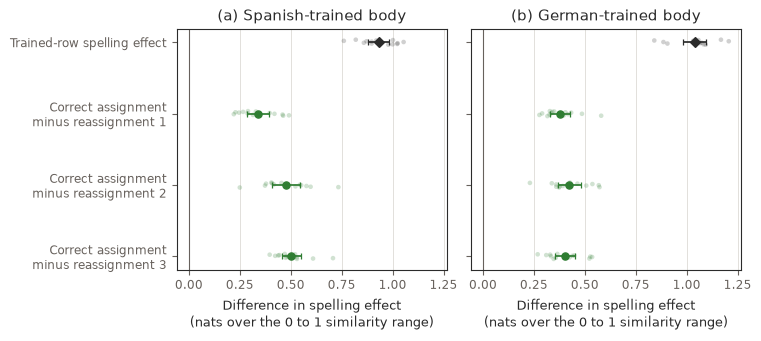

Larger-decoder comparisons 
 
 
 Comparison 
 Conclusion 
 Holm-adjusted p 
 
 
 
 
 Trained-row spelling effect 
 Supported 
 8.86e-15 
 
 
 Correctly assigned rows over reassigned rows 
 Supported 
 1.82e-09

Larger-decoder spelling effects 
 
 
 Language 
 Comparison 
 Estimate [95% interval] 
 
 
 
 
 Spanish 
 Trained-row spelling effect 
 0.931 [0.881, 0.980] 
 
 
 German 
 Trained-row spelling effect 
 1.038 [0.980, 1.097] 
 
 
 Spanish 
 Correct-assignment advantage, reassignment 1 
 0.339 [0.286, 0.392] 
 
 
 Spanish 
 Correct-assignment advantage, reassignment 2 
 0.478 [0.408, 0.547] 
 
 
 Spanish 
 Correct-assignment advantage, reassignment 3 
 0.502 [0.456, 0.548] 
 
 
 German 
 Correct-assignment advantage, reassignment 1 
 0.377 [0.329, 0.425] 
 
 
 German 
 Correct-assignment advantage, reassignment 2 
 0.422 [0.366, 0.479] 
 
 
 German 
 Correct-assignment advantage, reassignment 3 
 0.400 [0.351, 0.449]

In [19]:
larger_claims = read_study_table("larger_decoder_assignment", "claims.csv")
larger_components = read_study_table("larger_decoder_assignment", "components.csv")
larger_seed_estimates = read_study_table(
    "larger_decoder_assignment", "seed_estimates.csv"
)
larger_seed_counts = larger_seed_estimates.groupby(["contrast_id", "language"])[
    "seed"
].nunique()
assert larger_seed_counts.eq(14).all()

save_analysis_figure(
    plots.larger_decoder_assignment_effects(larger_components, larger_seed_estimates),
    "larger_decoder_assignment_effects",
)
display_table(
    claim_summary(larger_claims),
    caption="Larger-decoder comparisons",
    formats={"Holm-adjusted p": "{:.3g}"},
)

larger_component_table = larger_components.copy()
larger_component_table["Language"] = larger_component_table["language"].map(
    LANGUAGE_LABELS
)
larger_component_table["Comparison"] = "Trained-row spelling effect"
larger_assignment_rows = larger_component_table["claim_id"].eq(
    "correct_assignment_advantage"
)
larger_component_table.loc[larger_assignment_rows, "Comparison"] = (
    "Correct-assignment advantage, reassignment "
    + larger_component_table.loc[larger_assignment_rows, "contrast_id"].str.extract(
        r"map_(\d+)"
    )[0]
)
larger_component_table["Estimate [95% interval]"] = larger_component_table.apply(
    lambda row: interval(row["estimate"], row["ci_low"], row["ci_high"]), axis=1
)
display_table(
    larger_component_table[["Language", "Comparison", "Estimate [95% interval]"]],
    caption="Larger-decoder spelling effects",
)

## 4. Independent initialization

The final experiment copies rows unchanged between two independently initialized model families. There is no learned alignment or adapter. This asks whether sharing a training language is enough when the rows and body began from different starting weights.

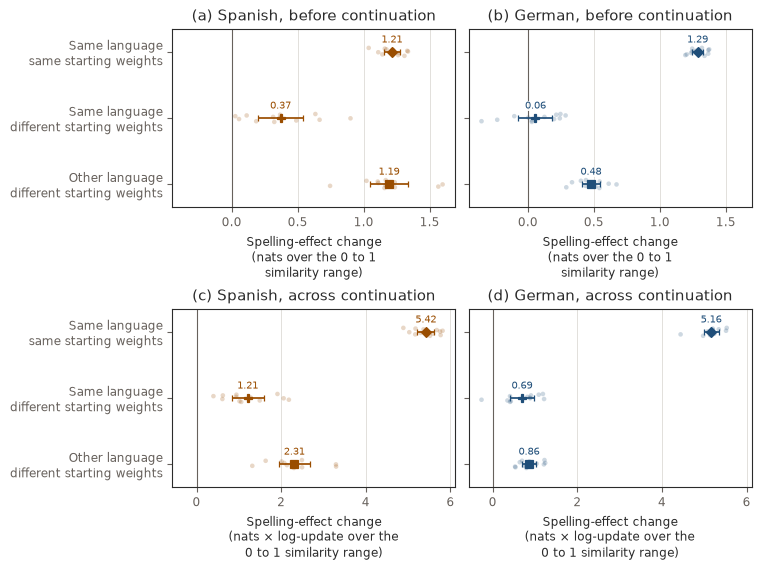

Independent-initialization comparisons 
 
 
 Comparison 
 Conclusion 
 Holm-adjusted p 
 
 
 
 
 Same-language spelling effect across different starting weights 
 Not supported 
 0.348 
 
 
 Same-language rows over other-language rows across different starting weights 
 Not supported 
 1

In [20]:
initialization_claims = read_study_table("independent_initialization", "claims.csv")
initialization_components = read_study_table(
    "independent_initialization", "components.csv"
)
initialization_pairs = read_study_table(
    "independent_initialization", "pair_estimates.csv"
)
initialization_conditions = read_study_table(
    "independent_initialization", "condition_effects.csv"
)
initialization_condition_pairs = read_study_table(
    "independent_initialization", "condition_pair_estimates.csv"
)
starting_weights_comparison = read_study_table(
    "independent_initialization", "starting_weights_comparison.csv"
)
initialization_checkpoints = read_study_table(
    "independent_initialization", "checkpoint_selectivity.csv"
)
initialization_word_surprisal = read_study_table(
    "independent_initialization", "word_surprisal.csv"
)
initialization_pair_counts = initialization_pairs.groupby(
    ["contrast_id", "language", "outcome"]
)["pair_id"].nunique()
assert initialization_pair_counts.eq(12).all()
condition_pair_counts = initialization_condition_pairs.groupby(
    ["condition", "language", "outcome"]
)["pair_id"].nunique()
assert condition_pair_counts.eq(12).all()

save_analysis_figure(
    plots.independent_initialization_spelling_effects(
        initialization_conditions, initialization_condition_pairs
    ),
    "independent_initialization_spelling_effects",
)
display_table(
    claim_summary(initialization_claims),
    caption="Independent-initialization comparisons",
    formats={"Holm-adjusted p": "{:.3g}"},
)

The prespecified same-language result is not consistent across both languages and outcomes. Its four estimates are positive, but the German step-zero interval includes zero. All four same-language-minus-other-language estimates point in the opposite direction from the prediction, and the step-zero contrast reverses sign by update 50.

In [21]:
initialization_component_table = initialization_components.copy()
initialization_component_table["Language"] = initialization_component_table[
    "language"
].map(LANGUAGE_LABELS)
initialization_component_table["Outcome"] = initialization_component_table[
    "outcome"
].map(OUTCOME_LABELS)
initialization_component_table["Comparison"] = initialization_component_table[
    "claim_id"
].map(
    {
        "same_language_effect_across_initializations": (
            "Same-language rows minus initial rows"
        ),
        "same_over_other_language_across_initializations": (
            "Same-language rows minus other-language rows"
        ),
    }
)
initialization_component_table["Estimate [95% interval]"] = (
    initialization_component_table.apply(
        lambda row: interval(row["estimate"], row["ci_low"], row["ci_high"]), axis=1
    )
)
display_table(
    initialization_component_table[
        ["Language", "Comparison", "Outcome", "Estimate [95% interval]"]
    ],
    caption="Independent-initialization estimates",
)

condition_table = initialization_conditions.copy()
condition_table["Language"] = condition_table["language"].map(LANGUAGE_LABELS)
condition_table["Condition"] = condition_table["condition"].map(
    {
        "same_language_same_starting_weights": "Same language, same starting weights",
        "same_language_different_starting_weights": "Same language, different starting weights",
        "other_language_different_starting_weights": "Other language, different starting weights",
    }
)
condition_table["Outcome"] = condition_table["outcome"].map(OUTCOME_LABELS)
condition_table["Estimate [95% interval]"] = condition_table.apply(
    lambda row: interval(row["estimate"], row["ci_low"], row["ci_high"]), axis=1
)
display_table(
    condition_table[["Language", "Condition", "Outcome", "Estimate [95% interval]"]],
    caption="Spelling effects by starting-weight relationship",
)

starting_weights_table = starting_weights_comparison.copy()
starting_weights_table["Language"] = starting_weights_table["language"].map(
    LANGUAGE_LABELS
)
starting_weights_table["Comparison"] = starting_weights_table["comparison"].map(
    {
        "same_language_same_starting_weights_effect": (
            "Same-language effect with the same starting weights"
        ),
        "reduction_when_starting_weights_differ": (
            "Reduction when starting weights differ"
        ),
    }
)
starting_weights_table["Outcome"] = starting_weights_table["outcome"].map(
    OUTCOME_LABELS
)
starting_weights_table["Estimate [95% interval]"] = starting_weights_table.apply(
    lambda row: interval(row["estimate"], row["ci_low"], row["ci_high"]), axis=1
)
display_table(
    starting_weights_table[
        ["Comparison", "Language", "Outcome", "Estimate [95% interval]"]
    ],
    caption="Starting-weight comparisons",
)

Independent-initialization estimates 
 
 
 Language 
 Comparison 
 Outcome 
 Estimate [95% interval] 
 
 
 
 
 Spanish 
 Same-language rows minus initial rows 
 Before English continuation 
 0.370 [0.202, 0.539] 
 
 
 Spanish 
 Same-language rows minus initial rows 
 Across English continuation 
 1.210 [0.836, 1.584] 
 
 
 German 
 Same-language rows minus initial rows 
 Before English continuation 
 0.057 [-0.072, 0.186] 
 
 
 German 
 Same-language rows minus initial rows 
 Across English continuation 
 0.692 [0.416, 0.968] 
 
 
 Spanish 
 Same-language rows minus other-language rows 
 Before English continuation 
 -0.822 [-1.019, -0.625] 
 
 
 Spanish 
 Same-language rows minus other-language rows 
 Across English continuation 
 -1.102 [-1.570, -0.634] 
 
 
 German 
 Same-language rows minus other-language rows 
 Before English continuation 
 -0.420 [-0.529, -0.312] 
 
 
 German 
 Same-language rows minus other-language rows 
 Across English continuation 
 -0.166 [-0.407, 0.075]

Spelling effects by starting-weight relationship 
 
 
 Language 
 Condition 
 Outcome 
 Estimate [95% interval] 
 
 
 
 
 Spanish 
 Same language, same starting weights 
 Before English continuation 
 1.214 [1.155, 1.273] 
 
 
 Spanish 
 Same language, different starting weights 
 Before English continuation 
 0.370 [0.202, 0.539] 
 
 
 Spanish 
 Other language, different starting weights 
 Before English continuation 
 1.192 [1.050, 1.335] 
 
 
 Spanish 
 Same language, same starting weights 
 Across English continuation 
 5.419 [5.221, 5.618] 
 
 
 Spanish 
 Same language, different starting weights 
 Across English continuation 
 1.210 [0.836, 1.584] 
 
 
 Spanish 
 Other language, different starting weights 
 Across English continuation 
 2.311 [1.946, 2.677] 
 
 
 German 
 Same language, same starting weights 
 Before English continuation 
 1.286 [1.244, 1.327] 
 
 
 German 
 Same language, different starting weights 
 Before English continuation 
 0.057 [-0.072, 0.186] 
 
 
 German 
 Other language, different starting weights 
 Before English continuation 
 0.478 [0.409, 0.547] 
 
 
 German 
 Same language, same starting weights 
 Across English continuation 
 5.161 [4.983, 5.340] 
 
 
 German 
 Same language, different starting weights 
 Across English continuation 
 0.692 [0.416, 0.968] 
 
 
 German 
 Other language, different starting weights 
 Across English continuation 
 0.858 [0.693, 1.023]

Starting-weight comparisons 
 
 
 Comparison 
 Language 
 Outcome 
 Estimate [95% interval] 
 
 
 
 
 Same-language effect with the same starting weights 
 Spanish 
 Before English continuation 
 1.214 [1.155, 1.273] 
 
 
 Same-language effect with the same starting weights 
 Spanish 
 Across English continuation 
 5.419 [5.221, 5.618] 
 
 
 Same-language effect with the same starting weights 
 German 
 Before English continuation 
 1.286 [1.244, 1.327] 
 
 
 Same-language effect with the same starting weights 
 German 
 Across English continuation 
 5.161 [4.983, 5.340] 
 
 
 Reduction when starting weights differ 
 Spanish 
 Before English continuation 
 0.844 [0.639, 1.048] 
 
 
 Reduction when starting weights differ 
 Spanish 
 Across English continuation 
 4.210 [3.721, 4.699] 
 
 
 Reduction when starting weights differ 
 German 
 Before English continuation 
 1.228 [1.097, 1.360] 
 
 
 Reduction when starting weights differ 
 German 
 Across English continuation 
 4.469 [4.200, 4.738]

### Checkpoint crossover

The sign of the same-language comparison changes after English continuation begins. At installation, other-language rows have the steeper spelling slope. From update 50 onward, same-language rows have the steeper slope in the mean. All saved checkpoints are shown because the learning-curve summary does not reveal this crossover.

In [22]:
checkpoint_selectivity_table = initialization_checkpoints.copy()
checkpoint_selectivity_table["Language"] = checkpoint_selectivity_table["language"].map(
    LANGUAGE_LABELS
)
checkpoint_selectivity_table["Estimate [95% interval]"] = (
    checkpoint_selectivity_table.apply(
        lambda row: interval(row["estimate"], row["ci95_low"], row["ci95_high"]),
        axis=1,
    )
)
display_table(
    checkpoint_selectivity_table[
        [
            "Language",
            "english_updates",
            "Estimate [95% interval]",
            "negative_count",
            "positive_count",
        ]
    ].rename(
        columns={
            "english_updates": "English updates",
            "negative_count": "Negative pairs",
            "positive_count": "Positive pairs",
        }
    ),
    caption="Other-language minus same-language spelling slope",
)

Other-language minus same-language spelling slope 
 
 
 Language 
 English updates 
 Estimate [95% interval] 
 Negative pairs 
 Positive pairs 
 
 
 
 
 Spanish 
 0 
 -0.822 [-1.019, -0.625] 
 12 
 0 
 
 
 Spanish 
 50 
 0.217 [0.174, 0.261] 
 0 
 12 
 
 
 Spanish 
 100 
 0.111 [0.056, 0.166] 
 1 
 11 
 
 
 Spanish 
 200 
 0.141 [0.111, 0.172] 
 0 
 12 
 
 
 Spanish 
 400 
 0.120 [0.083, 0.157] 
 0 
 12 
 
 
 Spanish 
 800 
 0.056 [0.027, 0.084] 
 1 
 11 
 
 
 Spanish 
 1500 
 0.069 [0.050, 0.088] 
 0 
 12 
 
 
 Spanish 
 3000 
 0.042 [0.028, 0.057] 
 0 
 12 
 
 
 Spanish 
 6000 
 0.036 [0.029, 0.042] 
 0 
 12 
 
 
 Spanish 
 6100 
 0.029 [0.021, 0.037] 
 0 
 12 
 
 
 German 
 0 
 -0.420 [-0.529, -0.312] 
 12 
 0 
 
 
 German 
 50 
 0.170 [0.102, 0.238] 
 0 
 12 
 
 
 German 
 100 
 0.195 [0.170, 0.221] 
 0 
 12 
 
 
 German 
 200 
 0.268 [0.249, 0.287] 
 0 
 12 
 
 
 German 
 400 
 0.183 [0.156, 0.211] 
 0 
 12 
 
 
 German 
 800 
 0.078 [0.049, 0.106] 
 1 
 11 
 
 
 German 
 1500 
 0.041 [0.026, 0.056] 
 0 
 12 
 
 
 German 
 3000 
 0.019 [0.001, 0.037] 
 3 
 9 
 
 
 German 
 6000 
 0.013 [0.004, 0.022] 
 3 
 9 
 
 
 German 
 6100 
 0.012 [0.002, 0.022] 
 3 
 9

### Mean whole-word surprisal

Rows copied from different starting weights have much higher English whole-word surprisal than initial rows or same-language rows that share the body's starting weights. Markers show condition means and 95% intervals over the twelve initialization pairs. The result table contains summary statistics rather than the twelve pair values, so this figure has no faint points. The high surprisal is why a steeper spelling slope should not be read as better average prediction.

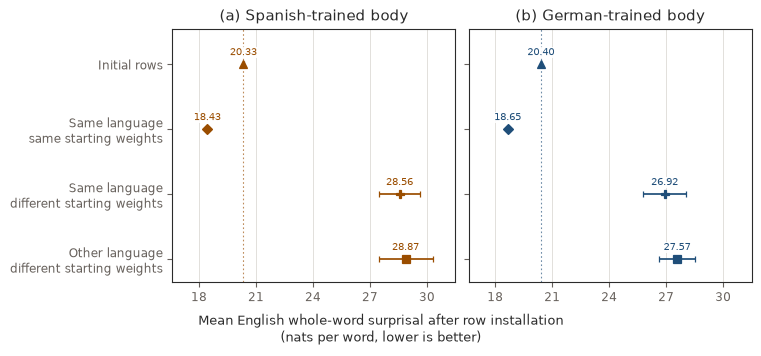

English whole-word surprisal at installation 
 
 
 Receiving body 
 Condition 
 Mean surprisal [95% interval] 
 
 
 
 
 Spanish-trained body 
 Initial rows 
 20.335 [20.319, 20.350] 
 
 
 Spanish-trained body 
 Same language, same starting weights 
 18.434 [18.382, 18.486] 
 
 
 Spanish-trained body 
 Same language, different starting weights 
 28.556 [27.454, 29.658] 
 
 
 Spanish-trained body 
 Other language, different starting weights 
 28.871 [27.451, 30.292] 
 
 
 German-trained body 
 Initial rows 
 20.402 [20.385, 20.418] 
 
 
 German-trained body 
 Same language, same starting weights 
 18.653 [18.605, 18.701] 
 
 
 German-trained body 
 Same language, different starting weights 
 26.918 [25.778, 28.057] 
 
 
 German-trained body 
 Other language, different starting weights 
 27.574 [26.625, 28.522]

In [23]:
save_analysis_figure(
    plots.independent_initialization_word_surprisal(initialization_word_surprisal),
    "independent_initialization_word_surprisal",
)

word_surprisal_table = initialization_word_surprisal.copy()
word_surprisal_table["Receiving body"] = word_surprisal_table["language"].map(
    BODY_LABELS
)
word_surprisal_table["Condition"] = word_surprisal_table["condition"].map(
    {
        "initial": "Initial rows",
        "same_language_same_starting_weights": "Same language, same starting weights",
        "same_language_different_starting_weights": "Same language, different starting weights",
        "other_language_different_starting_weights": "Other language, different starting weights",
    }
)
word_surprisal_table["Mean surprisal [95% interval]"] = word_surprisal_table.apply(
    lambda row: interval(row["mean"], row["ci95_low"], row["ci95_high"]), axis=1
)
display_table(
    word_surprisal_table[
        ["Receiving body", "Condition", "Mean surprisal [95% interval]"]
    ],
    caption="English whole-word surprisal at installation",
)

## Checks on the raw scale

Experiments 1 through 3 standardize each outcome within seed and condition. The table below repeats the cross-run and assignment directional comparisons in raw units. Every directional interval remains above zero. The step-zero and learning-curve coefficients have different units and should not be compared numerically.

In [24]:
raw_scale_components = read_study_table("robustness", "raw_scale_components.csv")
raw_scale_seed_estimates = read_study_table(
    "robustness", "raw_scale_seed_estimates.csv"
)
raw_seed_counts = raw_scale_seed_estimates.groupby(
    ["study", "component_id", "language", "outcome", "map_number"],
    dropna=False,
)["seed"].nunique()
assert raw_seed_counts.eq(12).all()

raw_scale_table = raw_scale_components.copy()
raw_scale_table["Study"] = raw_scale_table["study"].map(
    {
        "cross_run_transfer": "Transfer across training runs",
        "row_to_token_assignment": "Row-to-token assignment",
    }
)
raw_scale_table["Language"] = raw_scale_table["language"].map(LANGUAGE_LABELS)
raw_scale_table["Comparison"] = raw_scale_table["claim_id"].map(
    {
        "same_language_cross_run_effect": (
            "Same-language rows from another run minus initial rows"
        ),
        "same_language_over_other_language": (
            "Same-language rows from another run minus other-language rows"
        ),
        "correct_assignment_advantage": (
            "Reassigned rows minus correctly assigned rows"
        ),
    }
)
raw_scale_table["Outcome"] = raw_scale_table["outcome"].map(OUTCOME_LABELS)
raw_scale_table["Reassignment"] = raw_scale_table["map_number"].replace("", "–")
raw_scale_table["Estimate [95% interval]"] = raw_scale_table.apply(
    lambda row: interval(row["estimate"], row["ci_low"], row["ci_high"]), axis=1
)
display_table(
    raw_scale_table[
        [
            "Study",
            "Comparison",
            "Language",
            "Outcome",
            "Reassignment",
            "Estimate [95% interval]",
        ]
    ],
    caption="Directional comparisons in raw units",
)

Directional comparisons in raw units 
 
 
 Study 
 Comparison 
 Language 
 Outcome 
 Reassignment 
 Estimate [95% interval] 
 
 
 
 
 Transfer across training runs 
 Same-language rows from another run minus initial rows 
 Spanish 
 Before English continuation 
 – 
 1.253 [1.182, 1.324] 
 
 
 Transfer across training runs 
 Same-language rows from another run minus initial rows 
 Spanish 
 Across English continuation 
 – 
 5.488 [5.305, 5.671] 
 
 
 Transfer across training runs 
 Same-language rows from another run minus initial rows 
 German 
 Before English continuation 
 – 
 1.257 [1.201, 1.313] 
 
 
 Transfer across training runs 
 Same-language rows from another run minus initial rows 
 German 
 Across English continuation 
 – 
 5.071 [4.799, 5.344] 
 
 
 Transfer across training runs 
 Same-language rows from another run minus other-language rows 
 Spanish 
 Before English continuation 
 – 
 0.799 [0.710, 0.887] 
 
 
 Transfer across training runs 
 Same-language rows from another run minus other-language rows 
 Spanish 
 Across English continuation 
 – 
 4.286 [4.022, 4.550] 
 
 
 Transfer across training runs 
 Same-language rows from another run minus other-language rows 
 German 
 Before English continuation 
 – 
 0.957 [0.866, 1.049] 
 
 
 Transfer across training runs 
 Same-language rows from another run minus other-language rows 
 German 
 Across English continuation 
 – 
 4.333 [3.972, 4.695] 
 
 
 Row-to-token assignment 
 Reassigned rows minus correctly assigned rows 
 Spanish 
 Before English continuation 
 1 
 0.552 [0.481, 0.623] 
 
 
 Row-to-token assignment 
 Reassigned rows minus correctly assigned rows 
 Spanish 
 Across English continuation 
 1 
 3.862 [3.537, 4.187] 
 
 
 Row-to-token assignment 
 Reassigned rows minus correctly assigned rows 
 Spanish 
 Before English continuation 
 2 
 0.786 [0.705, 0.868] 
 
 
 Row-to-token assignment 
 Reassigned rows minus correctly assigned rows 
 Spanish 
 Across English continuation 
 2 
 4.152 [3.869, 4.435] 
 
 
 Row-to-token assignment 
 Reassigned rows minus correctly assigned rows 
 Spanish 
 Before English continuation 
 3 
 0.703 [0.639, 0.768] 
 
 
 Row-to-token assignment 
 Reassigned rows minus correctly assigned rows 
 Spanish 
 Across English continuation 
 3 
 3.918 [3.604, 4.232] 
 
 
 Row-to-token assignment 
 Reassigned rows minus correctly assigned rows 
 German 
 Before English continuation 
 1 
 0.492 [0.429, 0.555] 
 
 
 Row-to-token assignment 
 Reassigned rows minus correctly assigned rows 
 German 
 Across English continuation 
 1 
 3.507 [3.222, 3.793] 
 
 
 Row-to-token assignment 
 Reassigned rows minus correctly assigned rows 
 German 
 Before English continuation 
 2 
 0.512 [0.442, 0.582] 
 
 
 Row-to-token assignment 
 Reassigned rows minus correctly assigned rows 
 German 
 Across English continuation 
 2 
 3.369 [3.124, 3.613] 
 
 
 Row-to-token assignment 
 Reassigned rows minus correctly assigned rows 
 German 
 Before English continuation 
 3 
 0.478 [0.419, 0.537] 
 
 
 Row-to-token assignment 
 Reassigned rows minus correctly assigned rows 
 German 
 Across English continuation 
 3 
 3.535 [3.328, 3.741]